# Feature Importance Analysis
## Thailand Economic Model — Feature Catalog & Individual Analysis

**วัตถุประสงค์:** จัดหมวดหมู่ features ทั้งหมดที่ใช้ใน 3-Layer XGBoost model
แล้ววิเคราะห์ความสำคัญและน้ำหนักของแต่ละตัวด้วยเทคนิคต่างๆ

**Targets (สิ่งที่ model ทำนาย):**
- `SET_index_ret_w` — ผลตอบแทน SET Index รายสัปดาห์
- `gold_ret_w` — ผลตอบแทนทองคำรายสัปดาห์
- `USD_THB_ret_w` — ผลตอบแทน USD/THB รายสัปดาห์

**Training window:** 2010–2019 (SET), 2000–2019 (Gold, USD/THB)
**Test window:** 2020–present

---
### เทคนิคที่จะใช้วิเคราะห์
1. **Spearman Correlation** — monotonic relationship กับ target
2. **Rolling Spearman** — stability over time / regime
3. **Permutation Importance** — drop in model performance เมื่อ shuffle
4. **SHAP Values** — direction + magnitude ต่อ prediction รายสัปดาห์
5. **Feature Group Analysis** — รวม importance ตามหมวด


In [1]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
from sklearn.inspection import permutation_importance as sklearn_perm
import shap

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

RAW_DIR  = Path("../../data/raw")
PROC_DIR = Path("../../data/processed")

TARGETS = {
    "SET_index_ret_w": "SET Index (Weekly Return)",
    "gold_ret_w":      "Gold (Weekly Return)",
    "USD_THB_ret_w":   "USD/THB (Weekly Return)",
}

TRAIN_END  = "2019-12-31"
TEST_START = "2020-01-01"
print("Imports OK")


Imports OK


/home/ppt/notebook/Thailand-Economic-Analysis/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
base = pd.read_csv(PROC_DIR / "unified_weekly.csv", index_col=0, parse_dates=True)
print(f"Shape : {base.shape}")
print(f"Date  : {base.index.min().date()} → {base.index.max().date()}")
print(f"\nColumns ({len(base.columns)}):")
for c in sorted(base.columns):
    print(" ", c)


Shape : (1322, 53)
Date  : 2000-09-01 → 2025-12-26

Columns (53):
  SET_index_price
  SET_index_ret_w
  USD_THB_price
  USD_THB_ret_d_lag1
  USD_THB_ret_d_lag2
  USD_THB_ret_w
  business_invest_annual
  consumption_annual
  dxy_price
  dxy_ret_d_lag1
  dxy_ret_d_lag2
  dxy_ret_w
  eem_ret_d_lag1
  eem_ret_d_lag2
  exports_pct_gdp_annual
  gdp_growth_annual
  global_uncertainty
  gold_price
  gold_ret_w
  govt_debt_annual
  govt_expenditure_annual
  imports_pct_gdp_annual
  inflation_annual
  lending_rate_annual
  nasdaq_price
  nasdaq_ret_d_lag1
  nasdaq_ret_d_lag2
  nasdaq_ret_w
  oil_price
  oil_ret_d_lag1
  oil_ret_d_lag2
  oil_ret_w
  sp500_price
  sp500_ret_d_lag1
  sp500_ret_d_lag2
  sp500_ret_w
  th_exchange_rate_real
  th_property_prices
  th_uncertainty
  th_us_imports
  unemployment_annual
  us_10yr_treasury_price
  us_10yr_treasury_ret_w
  us_2yr_treasury_price
  us_2yr_treasury_ret_w
  us_consumer_sentiment
  us_cpi_monthly
  us_fed_funds_rate
  us_govt_spending
  us_indust

---
## Feature Catalog — จัดหมวดหมู่ทั้งหมด

โครงสร้าง feature แบ่งเป็น **9 หมวด** ตามธรรมชาติของข้อมูลและ layer ของ model


In [3]:
# ══════════════════════════════════════════════════════════════════════════════
# FEATURE CATALOG — ทุก feature ที่ใช้ใน training จัดหมวดตาม layer
# ══════════════════════════════════════════════════════════════════════════════

CATALOG = {

    # ── หมวด 1: Global Market Signals (yfinance — รายสัปดาห์) ─────────────────
    "G1_Global_Market": {
        "label": "Global Market Signals",
        "source": "yfinance",
        "freq": "weekly",
        "features": {
            "sp500_ret_w":             "S&P500 weekly return — global demand proxy",
            "nasdaq_ret_w":            "Nasdaq weekly return — risk-on/off signal",
            "us_10yr_treasury_ret_w":  "US 10Y bond weekly return — risk sentiment",
            "us_10yr_treasury_price":  "10Y yield level (%) — ใช้คำนวณ real yield",
            "us_2yr_treasury_price":   "3M T-Bill yield (%) — short end yield curve",
            "dxy_ret_w":               "US Dollar Index weekly return",
            "dxy_price":               "DXY level — ใช้ z-score normalize",
            "oil_ret_w":               "Crude Oil weekly return",
        },
    },

    # ── หมวด 2: US Macro Fundamentals (FRED — รายเดือน) ──────────────────────
    "G2_US_Macro": {
        "label": "US Macro Fundamentals",
        "source": "FRED",
        "freq": "monthly → forward-fill to weekly",
        "features": {
            "us_fed_funds_rate":     "Fed Funds Rate — กระทบ THB + capital flows",
            "us_cpi_monthly":        "US CPI — global inflation signal",
            "us_unemployment":       "US Unemployment Rate — global demand proxy",
            "us_industrial_prod":    "US Industrial Production — economic output",
            "us_consumer_sentiment": "US Consumer Sentiment — spending intent (leading)",
        },
    },

    # ── หมวด 3: Thailand Macro Fundamentals (FRED + World Bank) ───────────────
    "G3_TH_Macro": {
        "label": "Thailand Macro Fundamentals",
        "source": "FRED / World Bank",
        "freq": "monthly/annual → forward-fill",
        "features": {
            "th_exchange_rate_real": "Real Effective Exchange Rate THB (REER)",
            "th_us_imports":         "US imports from Thailand — bilateral trade flow",
            "th_property_prices":    "Bangkok property prices (BIS)",
            "lending_rate_annual":   "Thailand domestic lending rate (World Bank)",
            "gdp_growth_annual":     "Thailand GDP growth % YoY (World Bank)",
            "th_uncertainty":        "World Uncertainty Index — Thailand",
        },
    },

    # ── หมวด 4: Sentiment Proxy — Fear/Greed จากตลาด ─────────────────────────
    "G4_Sentiment_Proxy": {
        "label": "Market-Derived Sentiment Proxy",
        "source": "yfinance / FRED",
        "freq": "weekly / monthly",
        "note": "ทุก feature ใน group นี้ถูก Z-score normalize ก่อน train",
        "features": {
            "vix_price":               "VIX Fear Gauge — level สำคัญกว่า return",
            "vix_price_z":             "VIX Z-score (expanding)",
            "global_uncertainty":      "Global Economic Policy Uncertainty Index",
            "global_uncertainty_z":    "Global uncertainty Z-score",
            "us_consumer_sentiment_z": "US Consumer Sentiment Z-score",
        },
    },

    # ── หมวด 5: News Sentiment (Bangkok Post RSS + GDELT) ──────────────────────
    "G5_News_Sentiment": {
        "label": "News Sentiment Flow",
        "source": "Bangkok Post RSS + GDELT DOC API v2",
        "freq": "weekly aggregation",
        "note": "score = VADER_compound × importance × (1 + power_bonus) | clamp[-1,1]",
        "features": {
            "news_sentiment_score": "Importance-weighted VADER compound รายสัปดาห์",
            "news_article_count":   "จำนวนบทความต่อสัปดาห์",
            "news_power_words":     "จำนวน high-impact keywords พบ",
            "news_sent_3w_ma":      "Moving average 3 สัปดาห์",
            "news_sent_8w_ma":      "Moving average 8 สัปดาห์",
            "news_sent_momentum":   "Momentum ของ sentiment",
            "news_sent_z":          "Z-score ของ sentiment",
        },
    },

    # ── หมวด 6: Regime Dummies + Interaction Terms ────────────────────────────
    "G6_Regime_Interaction": {
        "label": "Market Regime Dummies & Signal×Regime Interactions",
        "source": "Derived from VIX percentile",
        "freq": "weekly",
        "note": "Regime: bull=VIX≤33pct | normal=33–67pct | crisis≥67pct",
        "features": {
            # Binary regime dummies
            "is_bull":   "VIX ≤ 33rd percentile — bull market regime",
            "is_normal": "VIX 33–67th percentile — normal regime",
            "is_crisis": "VIX ≥ 67th percentile — crisis/fear regime",
            # Signal × regime interactions
            "sp500_ret_w__x__is_bull":              "S&P500 × bull (momentum amplified)",
            "sp500_ret_w__x__is_normal":            "S&P500 × normal",
            "sp500_ret_w__x__is_crisis":            "S&P500 × crisis (panic amplified)",
            "vix_price_z__x__is_normal":            "VIX Z × normal",
            "vix_price_z__x__is_crisis":            "VIX Z × crisis (most impactful)",
            "gold_ret_w__x__is_bull":               "Gold × bull (low hedge demand)",
            "gold_ret_w__x__is_crisis":             "Gold × crisis (safe-haven demand)",
            "dxy_ret_w__x__is_bull":                "DXY × bull",
            "dxy_ret_w__x__is_normal":              "DXY × normal",
            "dxy_ret_w__x__is_crisis":              "DXY × crisis",
            "oil_ret_w__x__is_bull":                "Oil × bull (growth-driven)",
            "oil_ret_w__x__is_crisis":              "Oil × crisis (supply shock)",
            "us_10yr_treasury_ret_w__x__is_normal": "Bond × normal",
            "us_10yr_treasury_ret_w__x__is_crisis": "Bond × crisis (flight to safety)",
            "nasdaq_ret_w__x__is_bull":             "Nasdaq × bull",
            "nasdaq_ret_w__x__is_normal":           "Nasdaq × normal",
            "global_uncertainty_z__x__is_normal":   "Uncertainty Z × normal",
            "global_uncertainty_z__x__is_crisis":   "Uncertainty Z × crisis",
            "us_consumer_sentiment_z__x__is_bull":  "Consumer sentiment × bull",
            "us_consumer_sentiment_z__x__is_normal":"Consumer sentiment × normal",
        },
    },

    # ── หมวด 7: SET-Specific Features + Seasonality ───────────────────────────
    "G7_SET_Season": {
        "label": "SET-Specific Regime & Calendar Seasonality",
        "source": "Derived from SET price + calendar",
        "freq": "weekly",
        "features": {
            # SET trend regime (MA cross)
            "set_above_ma20w":      "SET > MA 20w (1=yes) — short-term trend",
            "set_above_ma52w":      "SET > MA 52w (1=yes) — primary bull/bear indicator",
            "set_ma_cross":         "MA20 > MA52 = golden cross (1=yes)",
            # SET drawdown
            "set_deep_drawdown":    "SET < -15% from 52w high — contrarian bounce zone",
            "set_near_high":        "SET within 3% of 52w high — momentum continuation",
            # Calendar seasonality
            "is_month_last_week":   "สัปดาห์สุดท้ายของเดือน — institutional rebalancing",
            "is_quarter_last_week": "สัปดาห์สุดท้ายของไตรมาส — larger rebalancing",
            "is_jan":               "เดือน ม.ค. — January effect",
            "is_dec":               "เดือน ธ.ค. — year-end bonus buying",
            "is_april":             "เดือน เม.ย. — Songkran low-volume dip",
            # USD/THB daily flow
            "usd_thb_d1_z":             "THB Thursday daily velocity Z-score",
            "usd_thb_d1__x__is_crisis": "THB velocity × crisis = capital flight signal",
        },
    },

    # ── หมวด 8: Cross-Market Daily Lag (Timezone Lead Effect) ─────────────────
    "G8_Daily_Lag": {
        "label": "Cross-Market Daily Lag Features (Timezone Lead)",
        "source": "yfinance daily → lagged to weekly",
        "freq": "daily lag → available before SET opens Friday",
        "note": "S&P500 Thu close (NY) = 4am Bangkok Fri → ก่อน SET เปิด 9:30am",
        "features": {
            "sp500_ret_d_lag1":   "S&P500 Thursday return ⭐ (strongest signal for SET)",
            "nasdaq_ret_d_lag1":  "Nasdaq Thursday — tech/risk-on signal",
            "eem_ret_d_lag1":     "EEM EM ETF Thursday — direct EM fund flow signal",
            "dxy_ret_d_lag1":     "DXY Thursday move — dollar strength overnight",
            "USD_THB_ret_d_lag1": "USD/THB Thursday move — FX flow before open",
            "gold_ret_d_lag1":    "Gold Thursday — safe-haven demand overnight",
            "oil_ret_d_lag1":     "Oil Thursday — commodity/risk overnight",
            # Daily lag × regime interactions
            "sp500_ret_d_lag1__x__is_bull":    "S&P overnight × bull (momentum amplified)",
            "sp500_ret_d_lag1__x__is_crisis":  "S&P overnight × crisis (panic amplified)",
            "eem_ret_d_lag1__x__is_bull":      "EEM × bull",
            "eem_ret_d_lag1__x__is_crisis":    "EEM × crisis",
            "dxy_ret_d_lag1__x__is_bull":      "DXY overnight × bull",
            "dxy_ret_d_lag1__x__is_crisis":    "DXY overnight × crisis",
            "USD_THB_ret_d_lag1__x__is_bull":  "USD/THB × bull",
            "USD_THB_ret_d_lag1__x__is_crisis":"USD/THB × crisis",
        },
    },

    # ── หมวด 9: Derived Signal Processing ────────────────────────────────────
    "G9_Derived": {
        "label": "Derived Signal Processing (Structural Macro + Momentum)",
        "source": "Engineered from raw features in model notebook",
        "freq": "weekly",
        "features": {
            # Real Yield & Yield Curve (Block H)
            "real_yield":            "10Y Yield − CPI YoY = Real Yield ⭐ (Gold driver #1)",
            "real_yield_chg4w":      "Real yield change over 4 weeks",
            "real_yield_z":          "Real yield Z-score",
            "yield_curve":           "10Y − 3M T-Bill Slope ⭐ (inverted = recession signal)",
            "yield_curve_chg4w":     "Yield curve change over 4 weeks",
            "yield_curve_inversion": "Inverted yield curve binary (1=inverted)",
            # Rate Carry (Block D)
            "rate_carry":                "US Fed Rate − TH Lending Rate (carry differential)",
            "rate_carry_chg":            "Carry change over 4 weeks",
            "rate_carry__x__is_normal":  "Carry signal ใน normal market (most effective)",
            "rate_carry__x__is_bull":    "Carry signal ใน bull market",
            # Seasonality Fourier (Block E)
            "month_sin": "sin(2π × month / 12) — smooth cyclical encoding",
            "month_cos": "cos(2π × month / 12)",
            "week_sin":  "sin(2π × week / 52)",
            "week_cos":  "cos(2π × week / 52)",
            # 52-Week Price Position (Block F — George & Hwang 2004)
            "SET_index_pct_from_52w_high": "SET % ห่างจาก 52w high",
            "SET_index_52w_range_pos":     "SET position ใน 52w range (0=low, 1=high)",
            "gold_pct_from_52w_high":      "Gold % from 52w high",
            "gold_52w_range_pos":          "Gold 52w range position",
            "USD_THB_pct_from_52w_high":   "USD/THB % from 52w high",
            "dxy_pct_from_52w_high":       "DXY % from 52w high",
            # VIX Dynamics (Block G)
            "vix_velocity":     "VIX pct_change(4w) — กำลังเร่งหรือลด",
            "vix_acceleration": "2nd derivative of VIX — crisis peak ผ่านไปหรือยัง",
            "vix_pullback":     "vix_z × (−velocity) = relief rally signal",
            # Long-Horizon Momentum (Block C — Jegadeesh & Titman 1993)
            "SET_index_ret_w_mom26w": "SET 6-month momentum",
            "SET_index_ret_w_mom52w": "SET 12-month momentum",
            "gold_ret_w_mom26w":      "Gold 6-month momentum",
            "gold_ret_w_mom52w":      "Gold 12-month momentum",
            "sp500_ret_w_mom26w":     "S&P500 6-month momentum",
            "dxy_ret_w_mom26w":       "DXY 6-month momentum",
            "dxy_ret_w_mom52w":       "DXY 12-month momentum",
            # Short-term lag
            "sp500_ret_w_lag1w": "S&P500 return lag 1 week",
            "sp500_ret_w_lag4w": "S&P500 return lag 4 weeks",
            "vix_price_lag1w":   "VIX level lag 1 week",
            "gold_ret_w_lag1w":  "Gold return lag 1 week",
            # SET Flow Composites (Block I6) — MUST_INCLUDE for SET model
            "eem_vs_sp500_lag1":   "EEM − S&P500 lag = EM excess return vs DM",
            "eem_ret_d_lag1_mom":  "EEM 3-week momentum",
            "em_outflow_pressure": "DXY↑ & VIX↑ & THB↓ = triple capital flight ⭐",
            "em_inflow_pressure":  "DXY↓ & VIX↓ & THB↑ = triple inflow signal",
            "risk_on_signal":      "S&P↑ & VIX↓ = confident bull",
            "risk_off_signal":     "S&P↓ & VIX↑ = risk-off flight to safety",
            "dxy_3w_mom":          "DXY 3-week momentum = sustained USD strength",
        },
    },
}

# ── Summary table ──────────────────────────────────────────────────────────────
rows = []
for group_id, info in CATALOG.items():
    for feat, desc in info["features"].items():
        rows.append({"group_id": group_id, "group_label": info["label"],
                     "feature": feat, "description": desc})
catalog_df = pd.DataFrame(rows)

print(f"Total features cataloged: {len(catalog_df)}")
print()
print(catalog_df.groupby("group_id")["feature"].count()
      .rename("n_features").to_string())


Total features cataloged: 122

group_id
G1_Global_Market          8
G2_US_Macro               5
G3_TH_Macro               6
G4_Sentiment_Proxy        5
G5_News_Sentiment         7
G6_Regime_Interaction    23
G7_SET_Season            12
G8_Daily_Lag             15
G9_Derived               41


---
## ตรวจสอบ Features ที่มีจริงใน Dataset

เปรียบเทียบ catalog กับ columns ที่มีจริงใน `unified_weekly.csv`


In [4]:
catalog_features = set(catalog_df["feature"].tolist())
actual_columns   = set(base.columns) - set(TARGETS.keys())

found   = catalog_features & actual_columns
missing = catalog_features - actual_columns
extra   = actual_columns - catalog_features

print(f"Catalog features           : {len(catalog_features)}")
print(f"Actual columns in dataset  : {len(actual_columns)}")
print(f"Found in data              : {len(found)}")
print(f"Cataloged but missing      : {len(missing)}  (ยังไม่ได้ engineer)")
print(f"In data but uncataloged    : {len(extra)}")

if missing:
    print("\n[Missing from data]:")
    for f in sorted(missing):
        print(" ", f)

if extra:
    print("\n[Extra (uncataloged) columns]:")
    for f in sorted(extra):
        print(" ", f)


Catalog features           : 122
Actual columns in dataset  : 50
Found in data              : 27
Cataloged but missing      : 95  (ยังไม่ได้ engineer)
In data but uncataloged    : 23

[Missing from data]:
  SET_index_52w_range_pos
  SET_index_pct_from_52w_high
  SET_index_ret_w_mom26w
  SET_index_ret_w_mom52w
  USD_THB_pct_from_52w_high
  USD_THB_ret_d_lag1__x__is_bull
  USD_THB_ret_d_lag1__x__is_crisis
  dxy_3w_mom
  dxy_pct_from_52w_high
  dxy_ret_d_lag1__x__is_bull
  dxy_ret_d_lag1__x__is_crisis
  dxy_ret_w__x__is_bull
  dxy_ret_w__x__is_crisis
  dxy_ret_w__x__is_normal
  dxy_ret_w_mom26w
  dxy_ret_w_mom52w
  eem_ret_d_lag1__x__is_bull
  eem_ret_d_lag1__x__is_crisis
  eem_ret_d_lag1_mom
  eem_vs_sp500_lag1
  em_inflow_pressure
  em_outflow_pressure
  global_uncertainty_z
  global_uncertainty_z__x__is_crisis
  global_uncertainty_z__x__is_normal
  gold_52w_range_pos
  gold_pct_from_52w_high
  gold_ret_d_lag1
  gold_ret_w__x__is_bull
  gold_ret_w__x__is_crisis
  gold_ret_w_lag1w
  gold

---
## Technique 1 — Spearman Rank Correlation

วิเคราะห์ความสัมพันธ์แบบ monotonic ระหว่างแต่ละ feature กับ target
- **ข้อดี:** ไม่สมมุติ linearity, robust ต่อ outlier
- **ข้อจำกัด:** ไม่บอก conditional importance (ขึ้นกับ regime อื่น)


In [5]:
train = base[base.index <= TRAIN_END].copy()
available_feats = [f for f in catalog_df["feature"].tolist() if f in train.columns]

spearman_rows = []
for target_col, target_label in TARGETS.items():
    if target_col not in train.columns:
        continue
    target_next = train[target_col].shift(-1).dropna()
    for feat in available_feats:
        aligned = pd.concat([train[feat].reindex(target_next.index),
                             target_next], axis=1).dropna()
        if len(aligned) < 20:
            continue
        r, p = spearmanr(aligned.iloc[:, 0], aligned.iloc[:, 1])
        spearman_rows.append({
            "target": target_label, "feature": feat,
            "spearman_r": round(r, 4), "abs_r": round(abs(r), 4),
            "p_value": round(p, 4), "significant": p < 0.05,
        })

spearman_df = pd.DataFrame(spearman_rows)

# แสดง top 20 per target
for target_label in TARGETS.values():
    sub = (spearman_df[spearman_df["target"] == target_label]
           .sort_values("abs_r", ascending=False).head(20))
    print(f"\n{'='*70}")
    print(f"  {target_label} — Top 20 by |Spearman r|")
    print(f"{'='*70}")
    print(sub[["feature", "spearman_r", "abs_r", "p_value", "significant"]]
          .to_string(index=False))



  SET Index (Weekly Return) — Top 20 by |Spearman r|
               feature  spearman_r  abs_r  p_value  significant
           sp500_ret_w      0.1454 0.1454   0.0000         True
    us_industrial_prod     -0.1444 0.1444   0.0000         True
          nasdaq_ret_w      0.1412 0.1412   0.0000         True
         th_us_imports     -0.1371 0.1371   0.0000         True
        eem_ret_d_lag1      0.1155 0.1155   0.0006         True
     gdp_growth_annual     -0.1141 0.1141   0.0005         True
   lending_rate_annual      0.1127 0.1127   0.0008         True
     nasdaq_ret_d_lag1      0.1118 0.1118   0.0004         True
      sp500_ret_d_lag1      0.1109 0.1109   0.0004         True
       us_unemployment      0.1074 0.1074   0.0014         True
 th_exchange_rate_real     -0.1029 0.1029   0.0023         True
    th_property_prices     -0.0976 0.0976   0.0038         True
        us_cpi_monthly     -0.0905 0.0905   0.0073         True
 us_consumer_sentiment     -0.0775 0.0775   0.0217

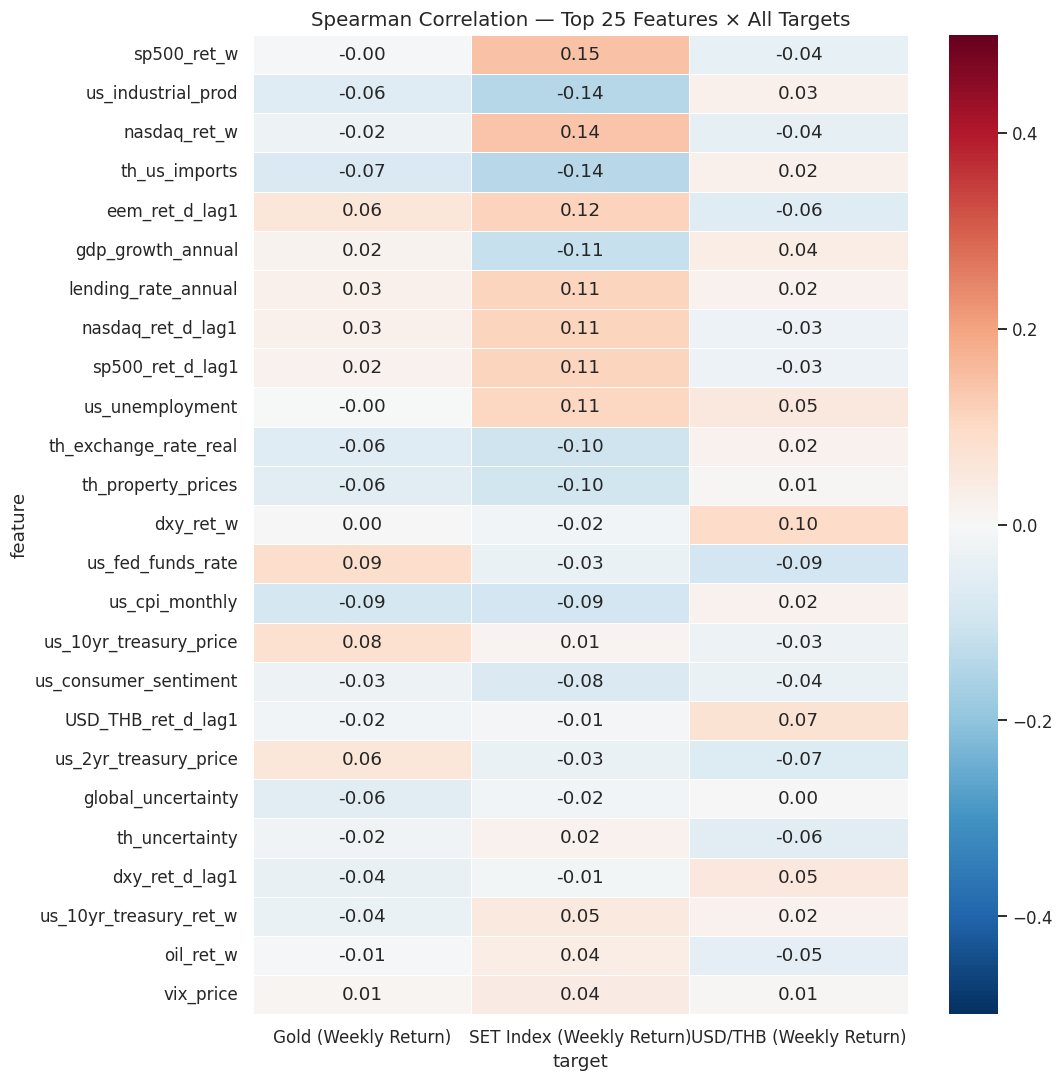

In [6]:
# Heatmap: top 25 features × 3 targets
top_feats = (spearman_df.groupby("feature")["abs_r"]
             .max().sort_values(ascending=False).head(25).index.tolist())

pivot = (spearman_df[spearman_df["feature"].isin(top_feats)]
         .pivot(index="feature", columns="target", values="spearman_r"))
pivot = pivot.loc[pivot.abs().max(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(10, 10))
sns.heatmap(pivot, annot=True, fmt=".2f", center=0,
            cmap="RdBu_r", vmin=-0.5, vmax=0.5,
            linewidths=0.5, ax=ax)
ax.set_title("Spearman Correlation — Top 25 Features × All Targets", fontsize=13)
plt.tight_layout()
plt.show()


---
## Technique 2 — Rolling Spearman (Feature Stability Over Time)

วิเคราะห์ว่า correlation คงที่ตลอดเวลาหรือเปลี่ยนตาม regime
- ถ้า rolling corr **ผันผวนมาก** = feature ไม่ stable → ระวัง overfit
- เส้นแดงประ = train/test split (2020)


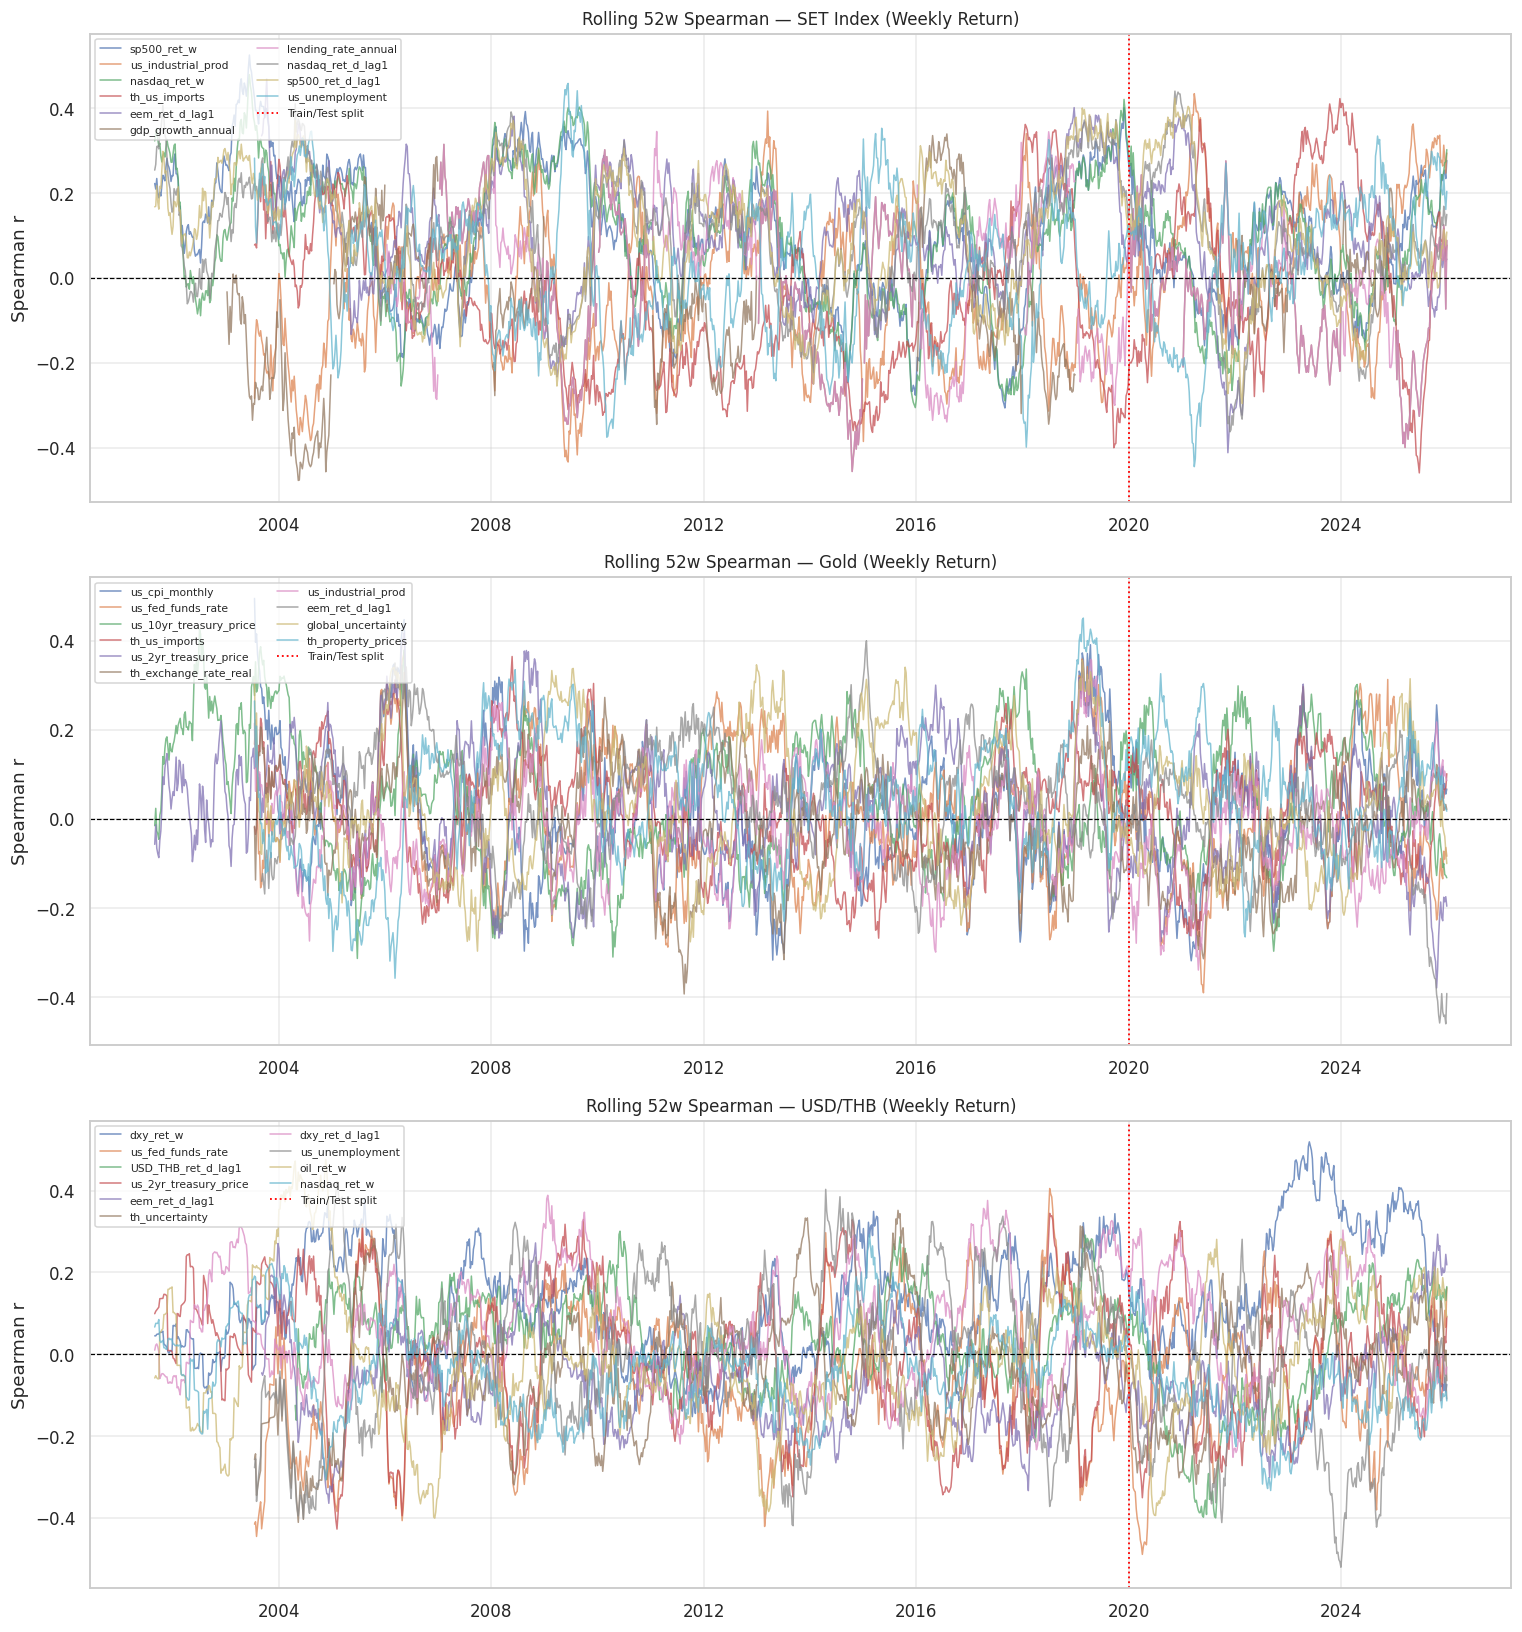

In [7]:
WINDOW = 52  # 1-year rolling window

fig, axes = plt.subplots(len(TARGETS), 1, figsize=(14, 5 * len(TARGETS)))
if len(TARGETS) == 1:
    axes = [axes]

for ax, (target_col, target_label) in zip(axes, TARGETS.items()):
    if target_col not in base.columns:
        continue

    top10 = (spearman_df[spearman_df["target"] == target_label]
             .sort_values("abs_r", ascending=False).head(10)["feature"].tolist())
    top10 = [f for f in top10 if f in base.columns]

    target_next = base[target_col].shift(-1)
    for feat in top10:
        roll_r, dates = [], []
        for end_i in range(WINDOW, len(base)):
            w_feat   = base[feat].iloc[end_i - WINDOW:end_i]
            w_target = target_next.iloc[end_i - WINDOW:end_i]
            aligned = pd.concat([w_feat, w_target], axis=1).dropna()
            r = spearmanr(aligned.iloc[:, 0], aligned.iloc[:, 1])[0] if len(aligned) >= 20 else np.nan
            roll_r.append(r)
            dates.append(base.index[end_i])
        ax.plot(dates, roll_r, alpha=0.75, linewidth=1, label=feat)

    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.axvline(pd.Timestamp(TEST_START), color="red", linewidth=1.2,
               linestyle=":", label="Train/Test split")
    ax.set_title(f"Rolling 52w Spearman — {target_label}", fontsize=11)
    ax.set_ylabel("Spearman r")
    ax.legend(fontsize=7, ncol=2, loc="upper left")
    ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()


---
## Technique 3 — Permutation Importance (Model-Based)

สุ่ม shuffle แต่ละ feature แล้วดูว่า model performance ตกลงเท่าไหร่
- **ข้อดี:** วัด actual contribution ใน fitted model
- **ข้อจำกัด:** ต้อง fit model ก่อน (ใช้ mini XGBoost เพื่อ analysis นี้)


In [8]:
from xgboost import XGBRegressor

def quick_fit(target_col, df, feature_cols, train_end):
    data = df[feature_cols + [target_col]].copy()
    data["_target"] = data[target_col].shift(-1)
    data = data.dropna()
    train = data[data.index <= train_end]
    X_tr = train[feature_cols].fillna(0).values
    y_tr = train["_target"].values
    model = XGBRegressor(
        n_estimators=200, max_depth=3, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.6,
        reg_alpha=1.0, reg_lambda=2.0,
        random_state=42, verbosity=0,
    )
    model.fit(X_tr, y_tr)
    return model, X_tr, y_tr, feature_cols

perm_results = {}
for target_col, target_label in TARGETS.items():
    if target_col not in base.columns:
        continue
    top_feats = (spearman_df[spearman_df["target"] == target_label]
                 .sort_values("abs_r", ascending=False).head(25)["feature"]
                 .tolist())
    top_feats = [f for f in top_feats if f in base.columns]
    if not top_feats:
        continue
    try:
        model, X_tr, y_tr, feat_names = quick_fit(target_col, base, top_feats, TRAIN_END)
        perm = sklearn_perm(model, X_tr, y_tr, n_repeats=10,
                            random_state=42, scoring="neg_mean_squared_error")
        perm_df = pd.DataFrame({
            "feature": feat_names,
            "importance_mean": perm.importances_mean,
            "importance_std":  perm.importances_std,
        }).sort_values("importance_mean", ascending=False)
        perm_results[target_col] = perm_df
        print(f"\n{target_label}:")
        print(perm_df.head(15).to_string(index=False))
    except Exception as e:
        print(f"[Skip] {target_label}: {e}")



SET Index (Weekly Return):
              feature  importance_mean  importance_std
    gdp_growth_annual     7.057418e-06    1.711733e-06
        th_us_imports     5.080052e-06    7.926619e-07
         nasdaq_ret_w     5.026352e-06    5.704851e-07
   us_industrial_prod     4.680442e-06    7.589025e-07
          sp500_ret_w     4.591940e-06    1.017443e-06
            oil_ret_w     4.166096e-06    5.364200e-07
            vix_price     2.223780e-06    3.171782e-07
       eem_ret_d_lag1     2.158286e-06    5.426884e-07
th_exchange_rate_real     1.723058e-06    3.765083e-07
      us_unemployment     1.627617e-06    4.409630e-07
   th_property_prices     1.322680e-06    8.233843e-08
            dxy_ret_w     1.272766e-06    2.736669e-07
us_2yr_treasury_price     1.004592e-06    2.333837e-07
    us_fed_funds_rate     8.927330e-07    2.327105e-07
            dxy_price     7.356775e-07    1.116695e-07

Gold (Weekly Return):
               feature  importance_mean  importance_std
        eem_r

SET Index exhibits strong sensitivity to global equity markets and macroeconomic indicators, particularly US equities and industrial production, indicating high global integration.

Gold is primarily driven by inflation and global risk factors, consistent with its safe-haven characteristics.

USD/THB model shows negligible dependence on external macro features, suggesting that short-term FX movements are largely dominated by autoregressive dynamics.

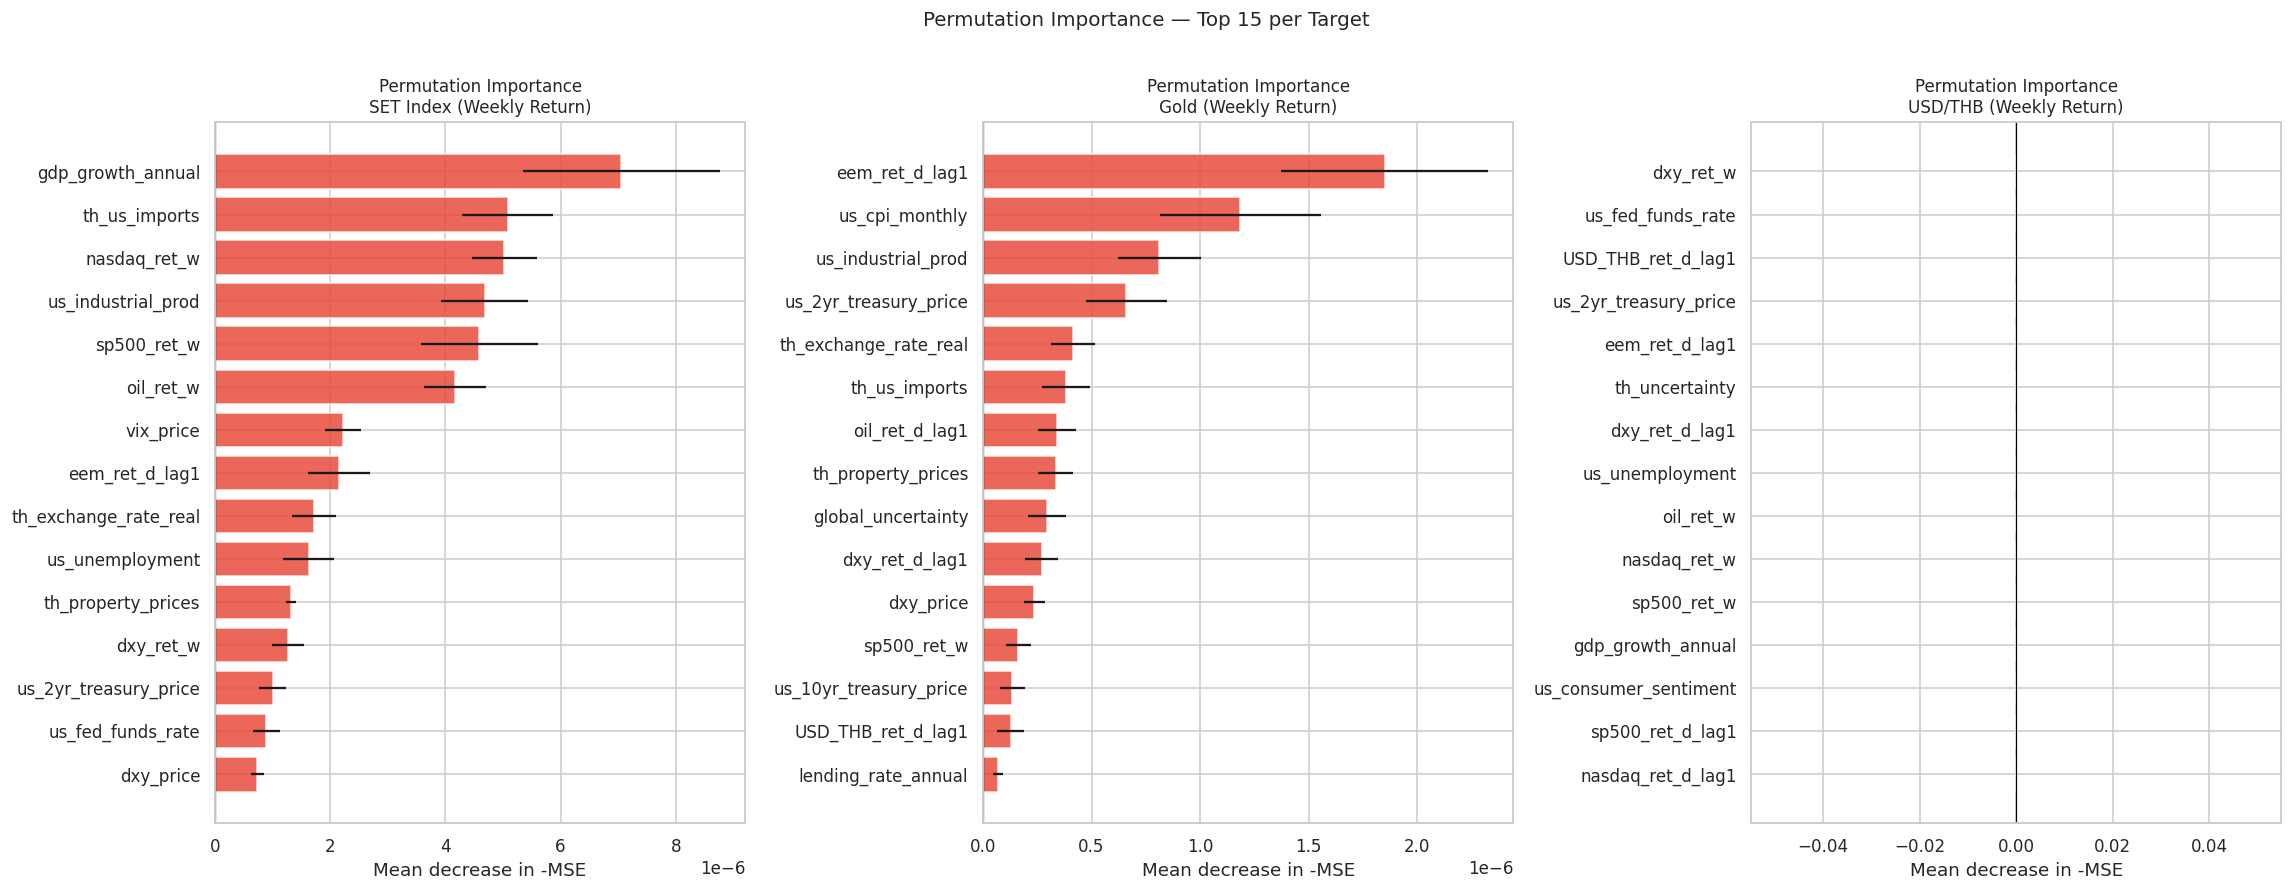

In [9]:
n_targets = len(perm_results)
if n_targets > 0:
    fig, axes = plt.subplots(1, n_targets, figsize=(7 * n_targets, 8))
    if n_targets == 1:
        axes = [axes]
    for ax, (target_col, perm_df) in zip(axes, perm_results.items()):
        top15 = perm_df.head(15)
        colors = ["#e74c3c" if v > 0 else "#95a5a6" for v in top15["importance_mean"]]
        ax.barh(top15["feature"][::-1], top15["importance_mean"][::-1],
                xerr=top15["importance_std"][::-1],
                color=colors[::-1], alpha=0.85, edgecolor="white")
        ax.axvline(0, color="black", linewidth=0.8)
        ax.set_title(f"Permutation Importance\n{TARGETS[target_col]}", fontsize=11)
        ax.set_xlabel("Mean decrease in -MSE")
    plt.suptitle("Permutation Importance — Top 15 per Target", fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()


---
## Technique 4 — SHAP Values

วิเคราะห์ contribution ของแต่ละ feature ต่อ prediction รายสัปดาห์
- **ข้อดี:** บอกทั้ง magnitude + direction
- **แกน x:** SHAP value บวก = ดัน prediction ขึ้น / ลบ = ดัน prediction ลง
- **สี dot:** แดง = feature value สูง, น้ำเงิน = feature value ต่ำ


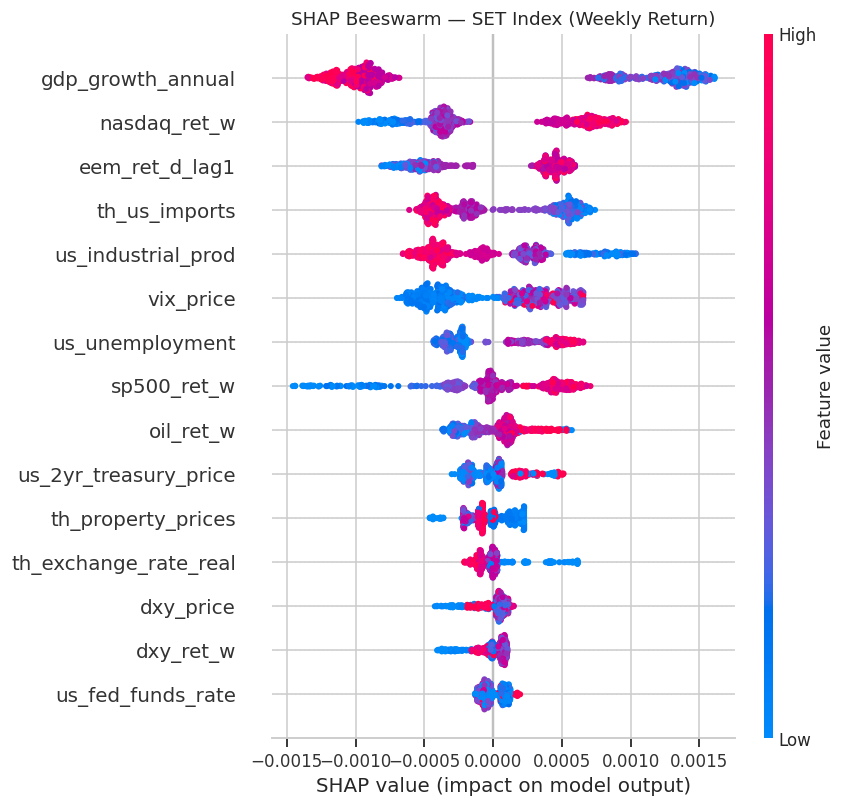

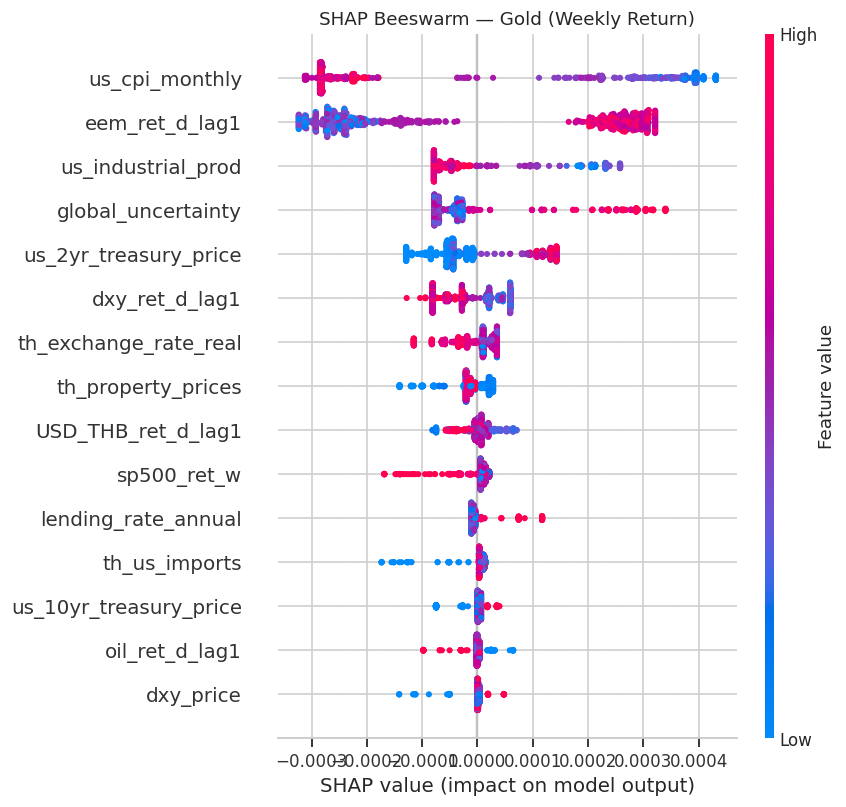

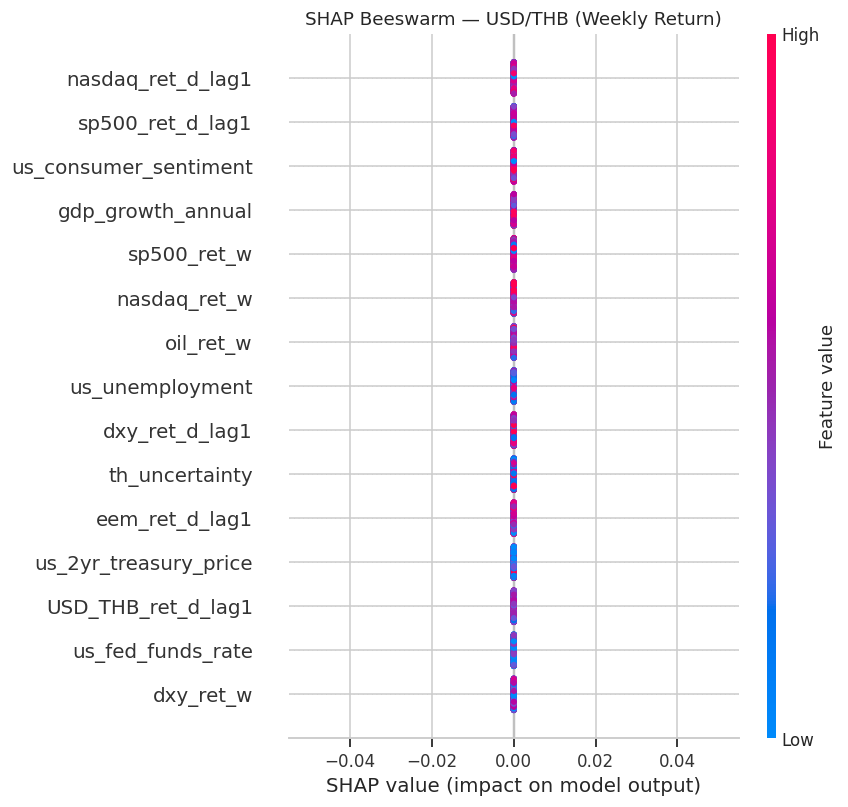

In [10]:
shap_results = {}
for target_col, target_label in TARGETS.items():
    if target_col not in base.columns or target_col not in perm_results:
        continue
    top_feats = perm_results[target_col].head(15)["feature"].tolist()
    top_feats = [f for f in top_feats if f in base.columns]
    if not top_feats:
        continue
    try:
        model, X_tr, y_tr, feat_names = quick_fit(target_col, base, top_feats, TRAIN_END)
        explainer = shap.TreeExplainer(model)
        shap_vals = explainer.shap_values(X_tr)
        shap_results[target_col] = (shap_vals, X_tr, feat_names)

        shap.summary_plot(shap_vals, X_tr, feature_names=feat_names,
                          show=False, plot_type="dot")
        plt.title(f"SHAP Beeswarm — {target_label}", fontsize=12)
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"[Skip] {target_label}: {e}")


---
## Technique 5 — Feature Group Importance

รวม importance ตาม group (หมวด) เพื่อดูว่า "ประเภท" ของข้อมูลไหนมีผลมากที่สุด


                                                                                avg     max  n
target                    group                                                               
Gold (Weekly Return)      US Macro Fundamentals                            0.052580  0.0888  5
                          Thailand Macro Fundamentals                      0.042300  0.0733  6
                          Market-Derived Sentiment Proxy                   0.033250  0.0579  2
                          Cross-Market Daily Lag Features (Timezone Lead)  0.030867  0.0589  6
                          Global Market Signals                            0.028563  0.0800  8
SET Index (Weekly Return) Thailand Macro Fundamentals                      0.097950  0.1371  6
                          US Macro Fundamentals                            0.090940  0.1444  5
                          Cross-Market Daily Lag Features (Timezone Lead)  0.066600  0.1155  6
                          Global Market Signals   

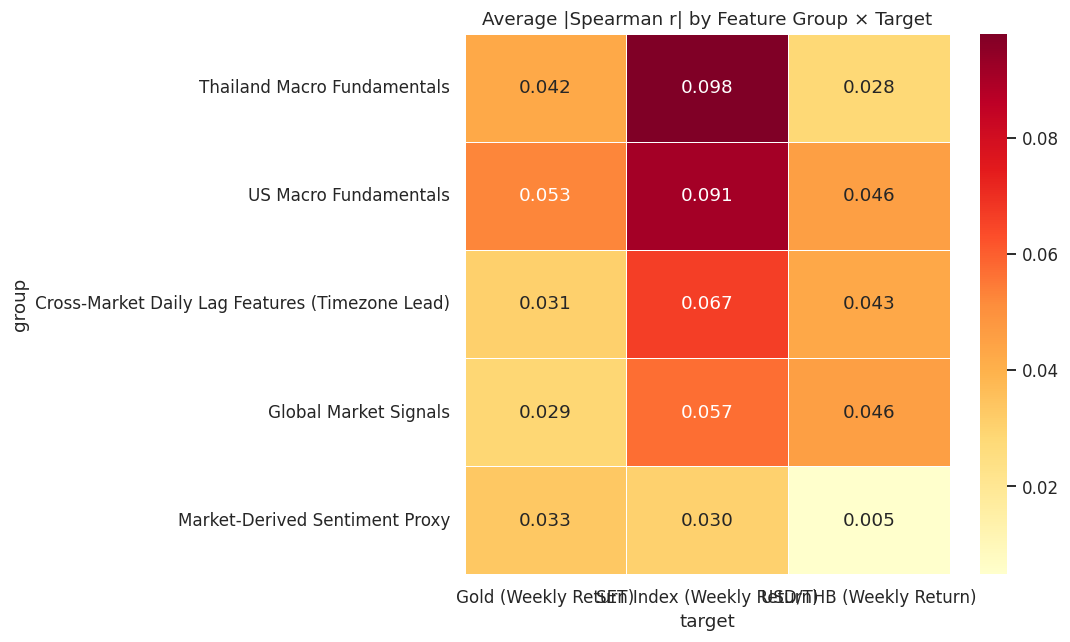

In [11]:
group_map = {}
for gid, info in CATALOG.items():
    for feat in info["features"]:
        group_map[feat] = info["label"]

spearman_df["group"] = spearman_df["feature"].map(group_map).fillna("Uncataloged")

group_importance = (spearman_df
                    .groupby(["target", "group"])["abs_r"]
                    .agg(avg=("mean"), max=("max"), n=("count"))
                    .sort_values(["target", "avg"], ascending=[True, False]))
print(group_importance.to_string())

pivot_group = (spearman_df.groupby(["group", "target"])["abs_r"]
               .mean().unstack("target").fillna(0))
pivot_group = pivot_group.loc[pivot_group.max(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(pivot_group, annot=True, fmt=".3f", cmap="YlOrRd",
            linewidths=0.5, ax=ax)
ax.set_title("Average |Spearman r| by Feature Group × Target", fontsize=12)
plt.tight_layout()
plt.show()


---
## Deep Dive — วิเคราะห์รายกลุ่ม

แต่ละ section = 1 หมวด feature
เพิ่ม analysis cell ต่อท้ายแต่ละ section ได้ตามต้องการ


### G1_Global_Market: Global Market Signals

**Source:** yfinance | **Freq:** weekly


| Feature | Description |
|---------|-------------|
| `sp500_ret_w` | S&P500 weekly return |
| `nasdaq_ret_w` | Nasdaq weekly return |
| `us_10yr_treasury_ret_w` | US 10Y bond weekly return |
| `us_10yr_treasury_price` | 10Y yield level (%) |
| `us_2yr_treasury_price` | 3M T-Bill yield (%) |
| `dxy_ret_w` | US Dollar Index weekly return |
| `dxy_price` | DXY level |
| `oil_ret_w` | Crude Oil weekly return |


Features available in dataset: 8
['sp500_ret_w', 'nasdaq_ret_w', 'us_10yr_treasury_ret_w', 'us_10yr_treasury_price', 'us_2yr_treasury_price', 'dxy_ret_w', 'dxy_price', 'oil_ret_w']

               feature  spearman_r  abs_r  p_value  significant
           sp500_ret_w      0.1454 0.1454   0.0000         True
          nasdaq_ret_w      0.1412 0.1412   0.0000         True
us_10yr_treasury_ret_w      0.0495 0.0495   0.1164        False
             oil_ret_w      0.0380 0.0380   0.2285        False
 us_2yr_treasury_price     -0.0337 0.0337   0.2856        False
             dxy_ret_w     -0.0190 0.0190   0.5476        False
             dxy_price     -0.0158 0.0158   0.6154        False
us_10yr_treasury_price      0.0139 0.0139   0.6593        False


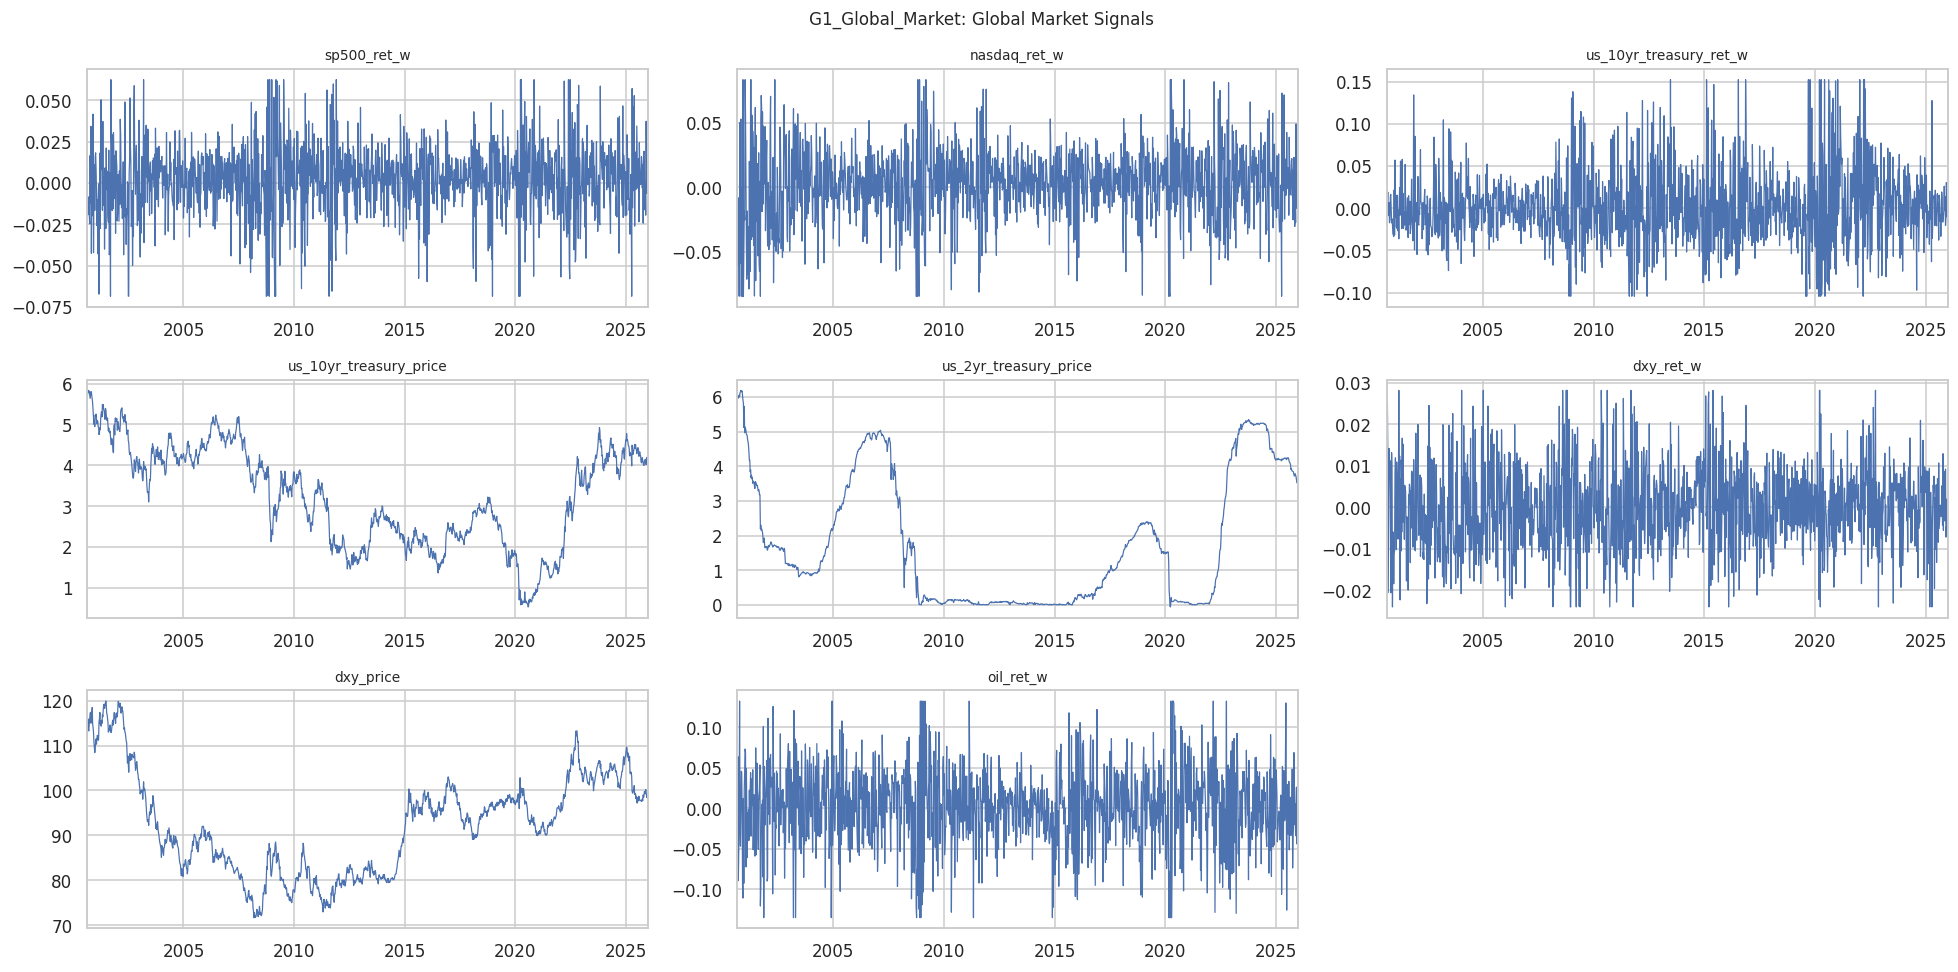

In [12]:
# ── G1_Global_Market: Global Market Signals ─────────────────────────────────────────
group_id    = "G1_Global_Market"
target_col  = "SET_index_ret_w"   # << เปลี่ยน target ได้
target_label = TARGETS[target_col]
group_feats = [f for f in CATALOG[group_id]["features"] if f in base.columns]

print(f"Features available in dataset: {len(group_feats)}")
print(group_feats)

# Spearman per feature
sub = (spearman_df[(spearman_df["feature"].isin(group_feats)) &
                   (spearman_df["target"] == target_label)]
       .sort_values("abs_r", ascending=False))
print()
if len(sub) > 0:
    print(sub[["feature","spearman_r","abs_r","p_value","significant"]]
          .to_string(index=False))
else:
    print("[No Spearman results — features may be missing from dataset]")

# Time series plot
n = len(group_feats)
if n > 0:
    cols_n = min(3, n)
    rows_n = (n + cols_n - 1) // cols_n
    fig, axes = plt.subplots(rows_n, cols_n, figsize=(6*cols_n, 3*rows_n))
    flat_axes = np.array(axes).flatten() if n > 1 else [axes]
    for ax, feat in zip(flat_axes, group_feats):
        base[feat].dropna().plot(ax=ax, linewidth=0.8)
        ax.set_title(feat, fontsize=9)
        ax.set_xlabel("")
    for ax in flat_axes[n:]:
        ax.set_visible(False)
    plt.suptitle(f"{group_id}: {CATALOG[group_id]['label']}", fontsize=11)
    plt.tight_layout()
    plt.show()
else:
    print("[No features available in dataset for this group]")

# TODO: เพิ่มการวิเคราะห์เพิ่มเติมที่ต้องการตรงนี้
# - Granger causality test
# - Regime-conditional correlation
# - Cross-correlation at various lags


### G2_US_Macro: US Macro Fundamentals

**Source:** FRED | **Freq:** monthly → weekly


| Feature | Description |
|---------|-------------|
| `us_fed_funds_rate` | Fed Funds Rate |
| `us_cpi_monthly` | US CPI |
| `us_unemployment` | US Unemployment Rate |
| `us_industrial_prod` | US Industrial Production |
| `us_consumer_sentiment` | US Consumer Sentiment |


Features available in dataset: 5
['us_fed_funds_rate', 'us_cpi_monthly', 'us_unemployment', 'us_industrial_prod', 'us_consumer_sentiment']

              feature  spearman_r  abs_r  p_value  significant
   us_industrial_prod     -0.1444 0.1444   0.0000         True
      us_unemployment      0.1074 0.1074   0.0014         True
       us_cpi_monthly     -0.0905 0.0905   0.0073         True
us_consumer_sentiment     -0.0775 0.0775   0.0217         True
    us_fed_funds_rate     -0.0349 0.0349   0.3011        False


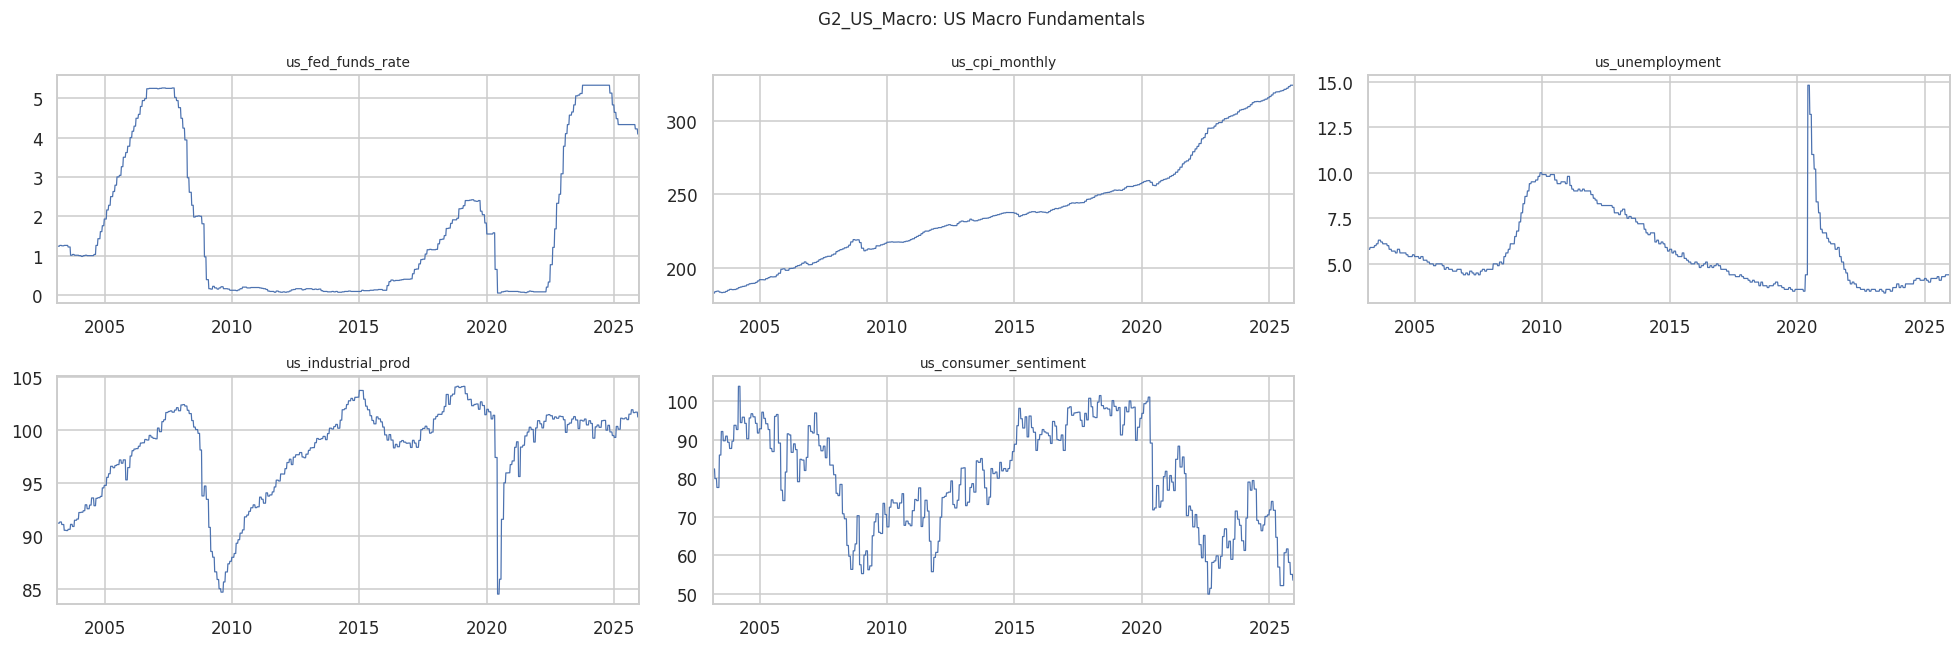

In [13]:
# ── G2_US_Macro: US Macro Fundamentals ─────────────────────────────────────────
group_id    = "G2_US_Macro"
target_col  = "SET_index_ret_w"   # << เปลี่ยน target ได้
target_label = TARGETS[target_col]
group_feats = [f for f in CATALOG[group_id]["features"] if f in base.columns]

print(f"Features available in dataset: {len(group_feats)}")
print(group_feats)

# Spearman per feature
sub = (spearman_df[(spearman_df["feature"].isin(group_feats)) &
                   (spearman_df["target"] == target_label)]
       .sort_values("abs_r", ascending=False))
print()
if len(sub) > 0:
    print(sub[["feature","spearman_r","abs_r","p_value","significant"]]
          .to_string(index=False))
else:
    print("[No Spearman results — features may be missing from dataset]")

# Time series plot
n = len(group_feats)
if n > 0:
    cols_n = min(3, n)
    rows_n = (n + cols_n - 1) // cols_n
    fig, axes = plt.subplots(rows_n, cols_n, figsize=(6*cols_n, 3*rows_n))
    flat_axes = np.array(axes).flatten() if n > 1 else [axes]
    for ax, feat in zip(flat_axes, group_feats):
        base[feat].dropna().plot(ax=ax, linewidth=0.8)
        ax.set_title(feat, fontsize=9)
        ax.set_xlabel("")
    for ax in flat_axes[n:]:
        ax.set_visible(False)
    plt.suptitle(f"{group_id}: {CATALOG[group_id]['label']}", fontsize=11)
    plt.tight_layout()
    plt.show()
else:
    print("[No features available in dataset for this group]")

# TODO: เพิ่มการวิเคราะห์เพิ่มเติมที่ต้องการตรงนี้
# - Granger causality test
# - Regime-conditional correlation
# - Cross-correlation at various lags


### G3_TH_Macro: Thailand Macro Fundamentals

**Source:** FRED / World Bank | **Freq:** monthly/annual


| Feature | Description |
|---------|-------------|
| `th_exchange_rate_real` | Real Effective Exchange Rate THB |
| `th_us_imports` | US imports from Thailand |
| `th_property_prices` | Bangkok property prices |
| `lending_rate_annual` | Thailand lending rate |
| `gdp_growth_annual` | Thailand GDP growth % YoY |
| `th_uncertainty` | World Uncertainty Index TH |


Features available in dataset: 6
['th_exchange_rate_real', 'th_us_imports', 'th_property_prices', 'lending_rate_annual', 'gdp_growth_annual', 'th_uncertainty']

              feature  spearman_r  abs_r  p_value  significant
        th_us_imports     -0.1371 0.1371   0.0000         True
    gdp_growth_annual     -0.1141 0.1141   0.0005         True
  lending_rate_annual      0.1127 0.1127   0.0008         True
th_exchange_rate_real     -0.1029 0.1029   0.0023         True
   th_property_prices     -0.0976 0.0976   0.0038         True
       th_uncertainty      0.0233 0.0233   0.4898        False


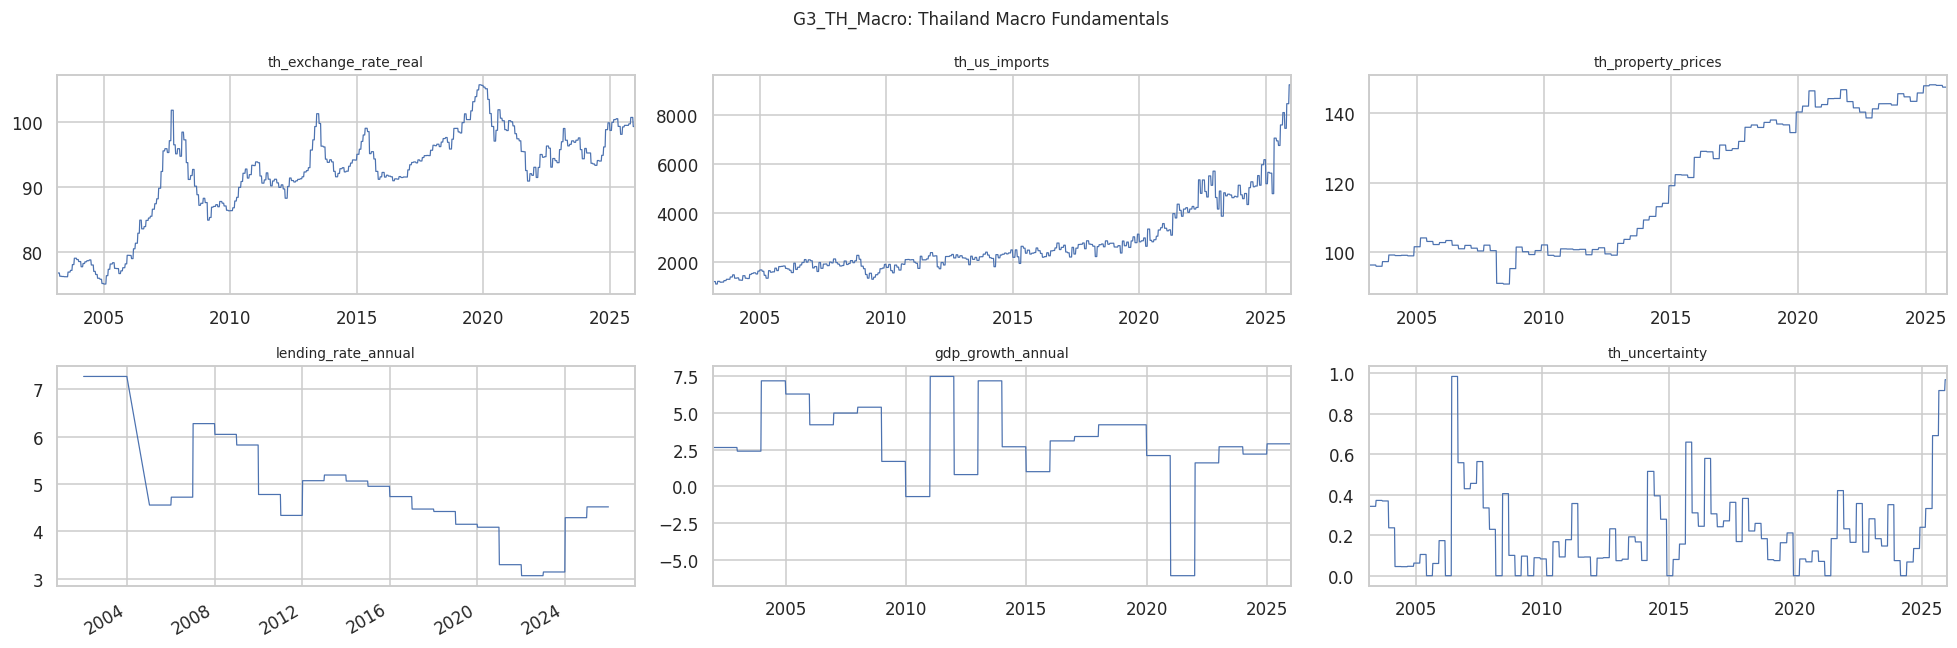

In [14]:
# ── G3_TH_Macro: Thailand Macro Fundamentals ─────────────────────────────────────────
group_id    = "G3_TH_Macro"
target_col  = "SET_index_ret_w"   # << เปลี่ยน target ได้
target_label = TARGETS[target_col]
group_feats = [f for f in CATALOG[group_id]["features"] if f in base.columns]

print(f"Features available in dataset: {len(group_feats)}")
print(group_feats)

# Spearman per feature
sub = (spearman_df[(spearman_df["feature"].isin(group_feats)) &
                   (spearman_df["target"] == target_label)]
       .sort_values("abs_r", ascending=False))
print()
if len(sub) > 0:
    print(sub[["feature","spearman_r","abs_r","p_value","significant"]]
          .to_string(index=False))
else:
    print("[No Spearman results — features may be missing from dataset]")

# Time series plot
n = len(group_feats)
if n > 0:
    cols_n = min(3, n)
    rows_n = (n + cols_n - 1) // cols_n
    fig, axes = plt.subplots(rows_n, cols_n, figsize=(6*cols_n, 3*rows_n))
    flat_axes = np.array(axes).flatten() if n > 1 else [axes]
    for ax, feat in zip(flat_axes, group_feats):
        base[feat].dropna().plot(ax=ax, linewidth=0.8)
        ax.set_title(feat, fontsize=9)
        ax.set_xlabel("")
    for ax in flat_axes[n:]:
        ax.set_visible(False)
    plt.suptitle(f"{group_id}: {CATALOG[group_id]['label']}", fontsize=11)
    plt.tight_layout()
    plt.show()
else:
    print("[No features available in dataset for this group]")

# TODO: เพิ่มการวิเคราะห์เพิ่มเติมที่ต้องการตรงนี้
# - Granger causality test
# - Regime-conditional correlation
# - Cross-correlation at various lags


### G4_Sentiment_Proxy: Market-Derived Sentiment Proxy

**Source:** yfinance / FRED | **Freq:** weekly

> **Note:** ทุก feature ใน group นี้ถูก Z-score normalize ก่อน train

| Feature | Description |
|---------|-------------|
| `vix_price` | VIX Fear Gauge |
| `vix_price_z` | VIX Z-score |
| `global_uncertainty` | Global Economic Policy Uncertainty |
| `global_uncertainty_z` | Global uncertainty Z-score |
| `us_consumer_sentiment_z` | US Consumer Sentiment Z-score |


Features available in dataset: 2
['vix_price', 'global_uncertainty']

           feature  spearman_r  abs_r  p_value  significant
         vix_price      0.0420 0.0420   0.1829        False
global_uncertainty     -0.0188 0.0188   0.5776        False


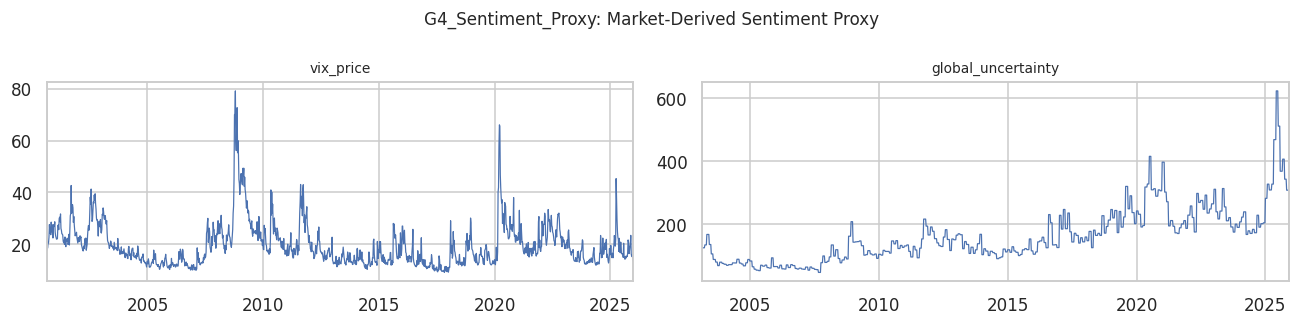

In [15]:
# ── G4_Sentiment_Proxy: Market-Derived Sentiment Proxy ─────────────────────────────────────────
group_id    = "G4_Sentiment_Proxy"
target_col  = "SET_index_ret_w"   # << เปลี่ยน target ได้
target_label = TARGETS[target_col]
group_feats = [f for f in CATALOG[group_id]["features"] if f in base.columns]

print(f"Features available in dataset: {len(group_feats)}")
print(group_feats)

# Spearman per feature
sub = (spearman_df[(spearman_df["feature"].isin(group_feats)) &
                   (spearman_df["target"] == target_label)]
       .sort_values("abs_r", ascending=False))
print()
if len(sub) > 0:
    print(sub[["feature","spearman_r","abs_r","p_value","significant"]]
          .to_string(index=False))
else:
    print("[No Spearman results — features may be missing from dataset]")

# Time series plot
n = len(group_feats)
if n > 0:
    cols_n = min(3, n)
    rows_n = (n + cols_n - 1) // cols_n
    fig, axes = plt.subplots(rows_n, cols_n, figsize=(6*cols_n, 3*rows_n))
    flat_axes = np.array(axes).flatten() if n > 1 else [axes]
    for ax, feat in zip(flat_axes, group_feats):
        base[feat].dropna().plot(ax=ax, linewidth=0.8)
        ax.set_title(feat, fontsize=9)
        ax.set_xlabel("")
    for ax in flat_axes[n:]:
        ax.set_visible(False)
    plt.suptitle(f"{group_id}: {CATALOG[group_id]['label']}", fontsize=11)
    plt.tight_layout()
    plt.show()
else:
    print("[No features available in dataset for this group]")

# TODO: เพิ่มการวิเคราะห์เพิ่มเติมที่ต้องการตรงนี้
# - Granger causality test
# - Regime-conditional correlation
# - Cross-correlation at various lags


### G5_News_Sentiment: News Sentiment Flow

**Source:** Bangkok Post RSS + GDELT | **Freq:** weekly aggregation

> **Note:** score = VADER_compound × importance × (1 + power_bonus)

| Feature | Description |
|---------|-------------|
| `news_sentiment_score` | Weighted VADER compound |
| `news_article_count` | บทความ/สัปดาห์ |
| `news_power_words` | High-impact keyword count |
| `news_sent_3w_ma` | 3w moving average |
| `news_sent_8w_ma` | 8w moving average |
| `news_sent_momentum` | Sentiment momentum |
| `news_sent_z` | Sentiment Z-score |


In [16]:
# ── G5_News_Sentiment: News Sentiment Flow ─────────────────────────────────────────
group_id    = "G5_News_Sentiment"
target_col  = "SET_index_ret_w"   # << เปลี่ยน target ได้
target_label = TARGETS[target_col]
group_feats = [f for f in CATALOG[group_id]["features"] if f in base.columns]

print(f"Features available in dataset: {len(group_feats)}")
print(group_feats)

# Spearman per feature
sub = (spearman_df[(spearman_df["feature"].isin(group_feats)) &
                   (spearman_df["target"] == target_label)]
       .sort_values("abs_r", ascending=False))
print()
if len(sub) > 0:
    print(sub[["feature","spearman_r","abs_r","p_value","significant"]]
          .to_string(index=False))
else:
    print("[No Spearman results — features may be missing from dataset]")

# Time series plot
n = len(group_feats)
if n > 0:
    cols_n = min(3, n)
    rows_n = (n + cols_n - 1) // cols_n
    fig, axes = plt.subplots(rows_n, cols_n, figsize=(6*cols_n, 3*rows_n))
    flat_axes = np.array(axes).flatten() if n > 1 else [axes]
    for ax, feat in zip(flat_axes, group_feats):
        base[feat].dropna().plot(ax=ax, linewidth=0.8)
        ax.set_title(feat, fontsize=9)
        ax.set_xlabel("")
    for ax in flat_axes[n:]:
        ax.set_visible(False)
    plt.suptitle(f"{group_id}: {CATALOG[group_id]['label']}", fontsize=11)
    plt.tight_layout()
    plt.show()
else:
    print("[No features available in dataset for this group]")

# TODO: เพิ่มการวิเคราะห์เพิ่มเติมที่ต้องการตรงนี้
# - Granger causality test
# - Regime-conditional correlation
# - Cross-correlation at various lags


Features available in dataset: 0
[]

[No Spearman results — features may be missing from dataset]
[No features available in dataset for this group]


### G6_Regime_Interaction: Market Regime Dummies & Signal×Regime Interactions

**Source:** Derived from VIX percentile | **Freq:** weekly

> **Note:** Regime: bull=VIX≤33pct | normal=33–67pct | crisis≥67pct

| Feature | Description |
|---------|-------------|
| `is_bull` | Bull regime |
| `is_normal` | Normal regime |
| `is_crisis` | Crisis regime |
| `sp500_ret_w__x__is_bull` | S&P500 × bull |
| `sp500_ret_w__x__is_normal` | S&P500 × normal |
| `sp500_ret_w__x__is_crisis` | S&P500 × crisis |
| `vix_price_z__x__is_normal` | VIX Z × normal |
| `vix_price_z__x__is_crisis` | VIX Z × crisis |
| `gold_ret_w__x__is_bull` | Gold × bull |
| `gold_ret_w__x__is_crisis` | Gold × crisis |
| `dxy_ret_w__x__is_bull` | DXY × bull |
| `dxy_ret_w__x__is_normal` | DXY × normal |
| `dxy_ret_w__x__is_crisis` | DXY × crisis |
| `oil_ret_w__x__is_bull` | Oil × bull |
| `oil_ret_w__x__is_crisis` | Oil × crisis |
| `us_10yr_treasury_ret_w__x__is_normal` | Bond × normal |
| `us_10yr_treasury_ret_w__x__is_crisis` | Bond × crisis |
| `nasdaq_ret_w__x__is_bull` | Nasdaq × bull |
| `nasdaq_ret_w__x__is_normal` | Nasdaq × normal |
| `global_uncertainty_z__x__is_normal` | Uncertainty Z × normal |
| `global_uncertainty_z__x__is_crisis` | Uncertainty Z × crisis |
| `us_consumer_sentiment_z__x__is_bull` | Consumer sentiment × bull |
| `us_consumer_sentiment_z__x__is_normal` | Consumer sentiment × normal |


In [17]:
# ── G6_Regime_Interaction: Market Regime Dummies & Signal×Regime Interactions ─────────────────────────────────────────
group_id    = "G6_Regime_Interaction"
target_col  = "SET_index_ret_w"   # << เปลี่ยน target ได้
target_label = TARGETS[target_col]
group_feats = [f for f in CATALOG[group_id]["features"] if f in base.columns]

print(f"Features available in dataset: {len(group_feats)}")
print(group_feats)

# Spearman per feature
sub = (spearman_df[(spearman_df["feature"].isin(group_feats)) &
                   (spearman_df["target"] == target_label)]
       .sort_values("abs_r", ascending=False))
print()
if len(sub) > 0:
    print(sub[["feature","spearman_r","abs_r","p_value","significant"]]
          .to_string(index=False))
else:
    print("[No Spearman results — features may be missing from dataset]")

# Time series plot
n = len(group_feats)
if n > 0:
    cols_n = min(3, n)
    rows_n = (n + cols_n - 1) // cols_n
    fig, axes = plt.subplots(rows_n, cols_n, figsize=(6*cols_n, 3*rows_n))
    flat_axes = np.array(axes).flatten() if n > 1 else [axes]
    for ax, feat in zip(flat_axes, group_feats):
        base[feat].dropna().plot(ax=ax, linewidth=0.8)
        ax.set_title(feat, fontsize=9)
        ax.set_xlabel("")
    for ax in flat_axes[n:]:
        ax.set_visible(False)
    plt.suptitle(f"{group_id}: {CATALOG[group_id]['label']}", fontsize=11)
    plt.tight_layout()
    plt.show()
else:
    print("[No features available in dataset for this group]")

# TODO: เพิ่มการวิเคราะห์เพิ่มเติมที่ต้องการตรงนี้
# - Granger causality test
# - Regime-conditional correlation
# - Cross-correlation at various lags


Features available in dataset: 0
[]

[No Spearman results — features may be missing from dataset]
[No features available in dataset for this group]


### G7_SET_Season: SET-Specific Regime & Calendar Seasonality

**Source:** Derived from SET price + calendar | **Freq:** weekly


| Feature | Description |
|---------|-------------|
| `set_above_ma20w` | SET > MA 20w |
| `set_above_ma52w` | SET > MA 52w (primary indicator) |
| `set_ma_cross` | Golden cross MA20 > MA52 |
| `set_deep_drawdown` | SET < -15% from 52w high |
| `set_near_high` | SET within 3% of 52w high |
| `is_month_last_week` | สัปดาห์สุดท้ายของเดือน |
| `is_quarter_last_week` | สัปดาห์สุดท้ายของไตรมาส |
| `is_jan` | เดือน ม.ค. |
| `is_dec` | เดือน ธ.ค. |
| `is_april` | เดือน เม.ย. Songkran |
| `usd_thb_d1_z` | THB Thursday velocity Z-score |
| `usd_thb_d1__x__is_crisis` | THB velocity × crisis |


In [18]:
# ── G7_SET_Season: SET-Specific Regime & Calendar Seasonality ─────────────────────────────────────────
group_id    = "G7_SET_Season"
target_col  = "SET_index_ret_w"   # << เปลี่ยน target ได้
target_label = TARGETS[target_col]
group_feats = [f for f in CATALOG[group_id]["features"] if f in base.columns]

print(f"Features available in dataset: {len(group_feats)}")
print(group_feats)

# Spearman per feature
sub = (spearman_df[(spearman_df["feature"].isin(group_feats)) &
                   (spearman_df["target"] == target_label)]
       .sort_values("abs_r", ascending=False))
print()
if len(sub) > 0:
    print(sub[["feature","spearman_r","abs_r","p_value","significant"]]
          .to_string(index=False))
else:
    print("[No Spearman results — features may be missing from dataset]")

# Time series plot
n = len(group_feats)
if n > 0:
    cols_n = min(3, n)
    rows_n = (n + cols_n - 1) // cols_n
    fig, axes = plt.subplots(rows_n, cols_n, figsize=(6*cols_n, 3*rows_n))
    flat_axes = np.array(axes).flatten() if n > 1 else [axes]
    for ax, feat in zip(flat_axes, group_feats):
        base[feat].dropna().plot(ax=ax, linewidth=0.8)
        ax.set_title(feat, fontsize=9)
        ax.set_xlabel("")
    for ax in flat_axes[n:]:
        ax.set_visible(False)
    plt.suptitle(f"{group_id}: {CATALOG[group_id]['label']}", fontsize=11)
    plt.tight_layout()
    plt.show()
else:
    print("[No features available in dataset for this group]")

# TODO: เพิ่มการวิเคราะห์เพิ่มเติมที่ต้องการตรงนี้
# - Granger causality test
# - Regime-conditional correlation
# - Cross-correlation at various lags


Features available in dataset: 0
[]

[No Spearman results — features may be missing from dataset]
[No features available in dataset for this group]


### G8_Daily_Lag: Cross-Market Daily Lag Features (Timezone Lead)

**Source:** yfinance daily → weekly | **Freq:** daily lag

> **Note:** S&P500 Thu close (NY) = 4am Bangkok Fri → ก่อน SET เปิด 9:30am

| Feature | Description |
|---------|-------------|
| `sp500_ret_d_lag1` | S&P500 Thursday return ⭐ |
| `nasdaq_ret_d_lag1` | Nasdaq Thursday |
| `eem_ret_d_lag1` | EEM EM ETF Thursday |
| `dxy_ret_d_lag1` | DXY Thursday |
| `USD_THB_ret_d_lag1` | USD/THB Thursday |
| `gold_ret_d_lag1` | Gold Thursday |
| `oil_ret_d_lag1` | Oil Thursday |
| `sp500_ret_d_lag1__x__is_bull` | S&P overnight × bull |
| `sp500_ret_d_lag1__x__is_crisis` | S&P overnight × crisis |
| `eem_ret_d_lag1__x__is_bull` | EEM × bull |
| `eem_ret_d_lag1__x__is_crisis` | EEM × crisis |
| `dxy_ret_d_lag1__x__is_bull` | DXY × bull |
| `dxy_ret_d_lag1__x__is_crisis` | DXY × crisis |
| `USD_THB_ret_d_lag1__x__is_bull` | USD/THB × bull |
| `USD_THB_ret_d_lag1__x__is_crisis` | USD/THB × crisis |


Features available in dataset: 6
['sp500_ret_d_lag1', 'nasdaq_ret_d_lag1', 'eem_ret_d_lag1', 'dxy_ret_d_lag1', 'USD_THB_ret_d_lag1', 'oil_ret_d_lag1']

           feature  spearman_r  abs_r  p_value  significant
    eem_ret_d_lag1      0.1155 0.1155   0.0006         True
 nasdaq_ret_d_lag1      0.1118 0.1118   0.0004         True
  sp500_ret_d_lag1      0.1109 0.1109   0.0004         True
    oil_ret_d_lag1      0.0398 0.0398   0.2072        False
    dxy_ret_d_lag1     -0.0119 0.0119   0.7070        False
USD_THB_ret_d_lag1     -0.0097 0.0097   0.7788        False


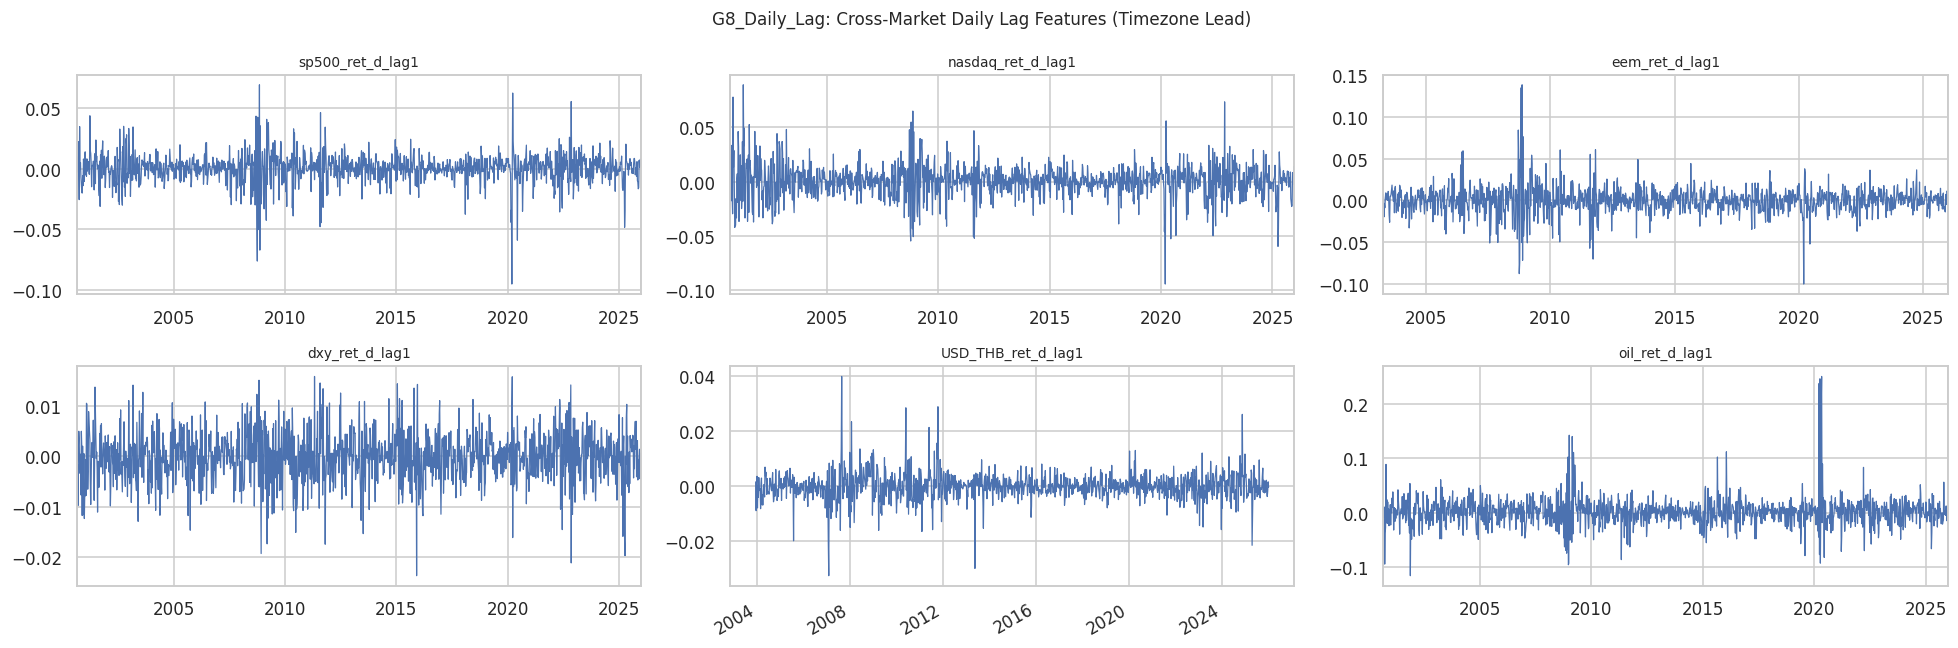

In [19]:
# ── G8_Daily_Lag: Cross-Market Daily Lag Features (Timezone Lead) ─────────────────────────────────────────
group_id    = "G8_Daily_Lag"
target_col  = "SET_index_ret_w"   # << เปลี่ยน target ได้
target_label = TARGETS[target_col]
group_feats = [f for f in CATALOG[group_id]["features"] if f in base.columns]

print(f"Features available in dataset: {len(group_feats)}")
print(group_feats)

# Spearman per feature
sub = (spearman_df[(spearman_df["feature"].isin(group_feats)) &
                   (spearman_df["target"] == target_label)]
       .sort_values("abs_r", ascending=False))
print()
if len(sub) > 0:
    print(sub[["feature","spearman_r","abs_r","p_value","significant"]]
          .to_string(index=False))
else:
    print("[No Spearman results — features may be missing from dataset]")

# Time series plot
n = len(group_feats)
if n > 0:
    cols_n = min(3, n)
    rows_n = (n + cols_n - 1) // cols_n
    fig, axes = plt.subplots(rows_n, cols_n, figsize=(6*cols_n, 3*rows_n))
    flat_axes = np.array(axes).flatten() if n > 1 else [axes]
    for ax, feat in zip(flat_axes, group_feats):
        base[feat].dropna().plot(ax=ax, linewidth=0.8)
        ax.set_title(feat, fontsize=9)
        ax.set_xlabel("")
    for ax in flat_axes[n:]:
        ax.set_visible(False)
    plt.suptitle(f"{group_id}: {CATALOG[group_id]['label']}", fontsize=11)
    plt.tight_layout()
    plt.show()
else:
    print("[No features available in dataset for this group]")

# TODO: เพิ่มการวิเคราะห์เพิ่มเติมที่ต้องการตรงนี้
# - Granger causality test
# - Regime-conditional correlation
# - Cross-correlation at various lags


### G9_Derived: Derived Signal Processing (Structural Macro + Momentum)

**Source:** Engineered in model notebook | **Freq:** weekly


| Feature | Description |
|---------|-------------|
| `real_yield` | 10Y Yield − CPI YoY ⭐ (Gold driver #1) |
| `real_yield_chg4w` | Real yield chg 4w |
| `real_yield_z` | Real yield Z-score |
| `yield_curve` | 10Y − 3M Slope ⭐ |
| `yield_curve_chg4w` | Yield curve chg 4w |
| `yield_curve_inversion` | Inverted (binary) |
| `rate_carry` | Fed Rate − TH Lending Rate |
| `rate_carry_chg` | Carry chg 4w |
| `rate_carry__x__is_normal` | Carry × normal |
| `rate_carry__x__is_bull` | Carry × bull |
| `month_sin` | sin(2π×month/12) |
| `month_cos` | cos(2π×month/12) |
| `week_sin` | sin(2π×week/52) |
| `week_cos` | cos(2π×week/52) |
| `SET_index_pct_from_52w_high` | SET % from 52w high |
| `SET_index_52w_range_pos` | SET 52w range pos |
| `gold_pct_from_52w_high` | Gold % from 52w high |
| `gold_52w_range_pos` | Gold 52w range pos |
| `USD_THB_pct_from_52w_high` | USD/THB % from 52w high |
| `dxy_pct_from_52w_high` | DXY % from 52w high |
| `vix_velocity` | VIX pct_change(4w) |
| `vix_acceleration` | 2nd derivative VIX |
| `vix_pullback` | vix_z × (−velocity) = relief rally |
| `SET_index_ret_w_mom26w` | SET 6m momentum |
| `SET_index_ret_w_mom52w` | SET 12m momentum |
| `gold_ret_w_mom26w` | Gold 6m momentum |
| `gold_ret_w_mom52w` | Gold 12m momentum |
| `sp500_ret_w_mom26w` | S&P500 6m momentum |
| `dxy_ret_w_mom26w` | DXY 6m momentum |
| `dxy_ret_w_mom52w` | DXY 12m momentum |
| `sp500_ret_w_lag1w` | S&P500 lag 1w |
| `sp500_ret_w_lag4w` | S&P500 lag 4w |
| `vix_price_lag1w` | VIX lag 1w |
| `gold_ret_w_lag1w` | Gold lag 1w |
| `eem_vs_sp500_lag1` | EEM − S&P500 = EM excess return vs DM |
| `eem_ret_d_lag1_mom` | EEM 3w momentum |
| `em_outflow_pressure` | DXY↑ & VIX↑ & THB↓ ⭐ |
| `em_inflow_pressure` | DXY↓ & VIX↓ & THB↑ |
| `risk_on_signal` | S&P↑ & VIX↓ |
| `risk_off_signal` | S&P↓ & VIX↑ |
| `dxy_3w_mom` | DXY 3w momentum |


In [20]:
# ── G9_Derived: Derived Signal Processing (Structural Macro + Momentum) ─────────────────────────────────────────
group_id    = "G9_Derived"
target_col  = "SET_index_ret_w"   # << เปลี่ยน target ได้
target_label = TARGETS[target_col]
group_feats = [f for f in CATALOG[group_id]["features"] if f in base.columns]

print(f"Features available in dataset: {len(group_feats)}")
print(group_feats)

# Spearman per feature
sub = (spearman_df[(spearman_df["feature"].isin(group_feats)) &
                   (spearman_df["target"] == target_label)]
       .sort_values("abs_r", ascending=False))
print()
if len(sub) > 0:
    print(sub[["feature","spearman_r","abs_r","p_value","significant"]]
          .to_string(index=False))
else:
    print("[No Spearman results — features may be missing from dataset]")

# Time series plot
n = len(group_feats)
if n > 0:
    cols_n = min(3, n)
    rows_n = (n + cols_n - 1) // cols_n
    fig, axes = plt.subplots(rows_n, cols_n, figsize=(6*cols_n, 3*rows_n))
    flat_axes = np.array(axes).flatten() if n > 1 else [axes]
    for ax, feat in zip(flat_axes, group_feats):
        base[feat].dropna().plot(ax=ax, linewidth=0.8)
        ax.set_title(feat, fontsize=9)
        ax.set_xlabel("")
    for ax in flat_axes[n:]:
        ax.set_visible(False)
    plt.suptitle(f"{group_id}: {CATALOG[group_id]['label']}", fontsize=11)
    plt.tight_layout()
    plt.show()
else:
    print("[No features available in dataset for this group]")

# TODO: เพิ่มการวิเคราะห์เพิ่มเติมที่ต้องการตรงนี้
# - Granger causality test
# - Regime-conditional correlation
# - Cross-correlation at various lags


Features available in dataset: 0
[]

[No Spearman results — features may be missing from dataset]
[No features available in dataset for this group]


---
## Save Outputs


In [21]:
catalog_df.to_csv(PROC_DIR / "feature_catalog.csv", index=False)
spearman_df.to_csv(PROC_DIR / "feature_spearman_corr.csv", index=False)
print(f"Saved feature_catalog.csv      ({len(catalog_df)} rows)")
print(f"Saved feature_spearman_corr.csv ({len(spearman_df)} rows)")


Saved feature_catalog.csv      (122 rows)
Saved feature_spearman_corr.csv (81 rows)
